In [1]:

#%pip install -U "jax[cuda13]"
# i still get: WARNING:2025-11-23 07:58:57,462:jax._src.xla_bridge:854: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
# I checked it out. it's because the bad guys are killing any cop who prevents the bad guys from forcing me to act out the perverted idiot man fantasies the bad guys have about me
#https://docs.jax.dev/en/latest/installation.html#install-nvidia-gpu says SM version needs to be > 7.5. mine is > 8; my driver is 581.32 and is listed in the link destination for the ubuntu experimental requirements
# moreover, i trid cupy, but that had issues too. 

# you used welch's t, but it wont catch mismatch variance. you should use Z or maybe Student's two sample t  

#students two sample t test:
t=(xbar1-xbar2) / sqrt(s2p((1/n1)+(1/n2)))
s2p is pooled variance
s2p=( (n1-1)s1**2 + (n2-2)s2**2 ) / dof
dof = n1+n2-2
stats.ttest_ind(vector1,vector2)  

#two sample z  
z= ((xbar1-xbar2)-(mu1-mu2)) / sqrt( (q1**2/n1)+(q2**2/n2) )  

at minimum add support or note to add support for robustness




rfecv  
class sklearn.feature_selection.RFECV(estimator,*,step=1,min_features_to_select=1,cv=None,scoring=None,verbose=0,n_jobs=None,importance_getter='auto')  


density based spacial clustering of application with noise (DBSCAN)
two parameters:
minPoints (in a cluster) must be >=num_featurns + 1 & >=3; genrally it's num_features*2
epsilon is based on features having same scale, and often with k-distance plot
>provides optimal number of clusters
>dendrograms help us to make clear visualizaitons
<time and space complexity is not suitable for large datasets
<no mathematical approach; each approach has disadvantages


-ipywidgets for notebooks:
import ipywidgets
from inpywidgets import interact
@interact
def toss_decision(team=list(df['toss_winner'].value_counts().index)):
    x=df.loc[(df['toss_winner']==team)]
    return x['toss_decision'].value_counts()
_______in a dict such as for utils.call:
def toss_decision(team):
    x = df.loc[df['toss_winner'] == team]
    return x['toss_decision'].value_counts()
my_dict = {    'my_func': interact(toss_decision,team=list(df['toss_winner'].value_counts().index))}
my_dict['my_func']

In [2]:
import subprocess
def gpu_available():
    try:
        subprocess.check_output(['nvidia-smi'])
        return True
    except Exception:
        return False
    
import platform
def is_linux():
    try:
        return platform.system() == 'Linux'
    except Exception:
        return False


import sys
def is_jax():
    if len([m for m in sys.modules.keys() if m.startswith('jax')])>0:
        return True
    return False

In [3]:
import sys
import re

pattern = re.compile(r'.*\.$')
matches = [name for name in sys.modules if pattern.match(name)]

print(matches)

[]


In [4]:
gpu=gpu_available()
linux=is_linux()

jax_=is_jax()  # this is used further into the code to aid in masking, wherease the gpu and linux are used in the following imports

if gpu is True and linux is True:
    print('Linux detected')
    print('GPU detected')
    import pandas as pd
    import cudf.pandas
    cudf.pandas.install()
    import cuml
    from cuml.naive_bayes import CategoricalNB
    import jax
    import jax.numpy as np
    import jax.scipy.special as jsp


else: 
    print(f"GPU: {gpu}\nLinux: {linux}")
    print(f"CuDF not available. Running Pandas")
    import pandas as pd
    from sklearn.naive_bayes import CategoricalNB
    import numpy as np



import scipy
import scipy.stats
from scipy.special import chdtrc  ###----> for jax: https://docs.jax.dev/en/latest/_autosummary/jax.scipy.stats.chi2.sf.html#jax.scipy.stats.chi2.sf

import os
import gc

import warnings

import matplotlib.pyplot as plt

import seaborn as sns

from itertools import combinations


pd.set_option('display.max_rows', None)# 
pd.set_option('display.width',None)#'display.max_columns', 50) # width  to prevent wrapping
pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.max_colwidth", None) # show full column content


GPU: False
Linux: True
CuDF not available. Running Pandas


In [5]:
import importlib.util

for lib in ["pandas", "cudf",'jax','numpy','cupy','cuml']:
    if importlib.util.find_spec(lib) is not None:
        print(f"{lib} is installed")
    else:
        print(f"{lib} is NOT installed")

pandas is installed
cudf is installed
jax is installed
numpy is installed
cupy is installed
cuml is installed


In [6]:
import sys
for lib in ["pandas", "cudf",'jax','numpy','cupy','cuml']:
    if lib in sys.modules:print(lib, ' in modules')
    else: print(lib,' NOT in modules')

pandas  in modules
cudf  NOT in modules
jax  NOT in modules
numpy  in modules
cupy  NOT in modules
cuml  NOT in modules


In [7]:
!nvidia-smi

Failed to initialize NVML: N/A
Failed to properly shut down NVML: N/A



In [8]:
"""
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zeesolver/consumer-behavior-and-shopping-habits-dataset")

print("Path to dataset files:", path)


import kaggle

!mkdir -p ~/.kaggle #creats kaggle dir in homefolder
!cp kaggle.json ~/.kaggle/ #accessed kaggle with your API
!chmod 600 ~/.kaggle/kaggle.json  # SECURITY    
#!kaggle datasets list  # use api
!kaggle datasets download -d "zeesolver/consumer-behavior-and-shopping-habits-dataset" # download a specific dataset

"""

'\nimport kagglehub\n\n# Download latest version\npath = kagglehub.dataset_download("zeesolver/consumer-behavior-and-shopping-habits-dataset")\n\nprint("Path to dataset files:", path)\n\n\nimport kaggle\n\n!mkdir -p ~/.kaggle #creats kaggle dir in homefolder\n!cp kaggle.json ~/.kaggle/ #accessed kaggle with your API\n!chmod 600 ~/.kaggle/kaggle.json  # SECURITY    \n#!kaggle datasets list  # use api\n!kaggle datasets download -d "zeesolver/consumer-behavior-and-shopping-habits-dataset" # download a specific dataset\n\n'

In [9]:
filepath="consumer-behavior-and-shopping-habits-dataset.zip"
import zipfile
with zipfile.ZipFile(filepath,'r') as data:
    data.extractall()
    with data.open("shopping_behavior_updated.csv") as behavior:
        df=pd.read_csv(behavior)
    #with data.open("shopping_trends.csv") as trends:
        #df2=pd.read_csv(trends)


func complete  


CATEGORICAL // CONTINIOUS
1)
funcs to:
-variable observed percentages  (or group then pct if nunique is large)
-tables P
-P(tables) no cancel
-P(x) given var val
-expected value
-chi
-such as a cat x coeff on a cat y outcome
-count plots (w/ and w/o hue)
-pie charts
-logistic
-target column(s)
-anova
-optimized correlation
-univariate (countplot,histplot)
-bivariate {catcat:[crosstab[plot(bar,stacked=False)plot(area)w/.all(1>0)]],catnum:[boxen,bax],numnum:}
-multivariate (heatmap(s),barshart(s)w/hue)



-ipywidgets for notebooks:
import ipywidgets
from inpywidgets import interact
@interact
def toss_decision(team=list(df['toss_winner'].value_counts().index)):
    x=df.loc[(df['toss_winner']==team)]
    return x['toss_decision'].value_counts()
_______in a dict such as for utils.call:
def toss_decision(team):
    x = df.loc[df['toss_winner'] == team]
    return x['toss_decision'].value_counts()
my_dict = {    'my_func': interact(toss_decision,team=list(df['toss_winner'].value_counts().index))}
my_dict['my_func']

In [10]:
#df.select_dtypes('number').head()
#df.select_dtypes('object').head()
#df.select_dtypes('category').head()
#df.select_dtypes('datetime').head()

In [11]:
mymap={'Yes':1,'No':0}
for col in ['Subscription Status', 'Discount Applied']:
    df[col]=df[col].map(mymap).astype('object')


super simple streamlit AI

In [12]:
"""
import streamlit as st
from mcp import Client  # hypothetical MCP client

# Connect to MCP model
client = Client("http://localhost:8000")

st.title("Streamlit + MCP Example")

user_input = st.text_input("Ask the model:")

if user_input:
    response = client.query({"prompt": user_input})
    st.write("Model says:", response["output"])
"""

'\nimport streamlit as st\nfrom mcp import Client  # hypothetical MCP client\n\n# Connect to MCP model\nclient = Client("http://localhost:8000")\n\nst.title("Streamlit + MCP Example")\n\nuser_input = st.text_input("Ask the model:")\n\nif user_input:\n    response = client.query({"prompt": user_input})\n    st.write("Model says:", response["output"])\n'

from mcp.server.fastmcp import FastMCP


# Create an MCP server
mcp = FastMCP("Weather Service")

# Tool implementation
@mcp.tool()
def get_weather(location: str) -> str:
    """Get the current weather for a specified location."""
    return f"Weather in {location}: Sunny, 72°F"

# Resource implementation
@mcp.resource("weather://{location}")
def weather_resource(location: str) -> str:
    """Provide weather data as a resource."""
    return f"Weather data for {location}: Sunny, 72°F"

# Prompt implementation 
@mcp.prompt()
def weather_report(location: str) -> str:
    """Create a weather report prompt."""
    return f"""You are a weather reporter. Weather report for {location}?"""


# Run the server
if __name__ == "__main__":
    mcp.run()

from    https://github.com/Clffordojuka/MCP-client/blob/main/app.py    
      
from dotenv import load_dotenv
from openai import OpenAI
import streamlit as st
import io
import os

load_dotenv()

# Load environment variables from .env file
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HF_API_KEY = os.getenv("HF_API_KEY")

# Check if the keys are loaded correctly
if not OPENAI_API_KEY or not HF_API_KEY:
    raise ValueError("Missing API keys")
# Example usage of the API keys
def use_openai_api():
    print(f"Using OpenAI API with key: {OPENAI_API_KEY}")

def use_huggingface_api():
    print(f"Using Hugging Face API with key: {HF_API_KEY}")

# streamlit setup
def initialize_page():
    """Initialize the Streamlit page configuration and layout"""
    st.set_page_config(
        page_title="Streamlit MCP Client",
        page_icon="🤖",
        layout="centered",
        initial_sidebar_state="auto"
    )
    st.markdown(
        """
        <style>
        .main {background-color: #f5f6fa;}
        .stButton>button {background-color: #4F8BF9; color: white;}
        .stTextArea textarea {background-color: #f0f4ff;}
        </style>
        """,
        unsafe_allow_html=True
    )
    st.title("🤖 Streamlit MCP Client")
    st.caption("Ask about any topic and get resources or summaries from your selected MCP server.")

    # Add a horizontal line for separation
    st.markdown("---")

    # Return a column object which can be used to place widgets
    return st.columns(1)[0]

def get_user_input(column):
    """Handle transcript input methods and return the transcript text"""

    with column:
        st.subheader("Enter Your Topic")
        user_text = st.text_area(
            "What are you interested in?",
            height=100,
            placeholder="E.g., Python web frameworks, quantum computing, etc.",
            help="Type your topic of interest here."
        )
    return user_text

def create_mcp_server_dropdown():
    mcp_servers = {
        "deepwiki": "https://mcp.deepwiki.com/mcp",
        "huggingface": "https://huggingface.co/mcp"
    }
    st.subheader("Choose MCP Server")
    selected_server = st.radio(
        "",
        options=list(mcp_servers.keys()),
        format_func=lambda x: "DeepWiki" if x == "deepwiki" else "HuggingFace",
        horizontal=True,
        help="Choose the MCP server you want to connect to"
    )
    server_url = mcp_servers[selected_server]
    st.caption(f"Selected server: `{server_url}`")
    return selected_server, server_url

#generate the transcript
def generate_response(user_text, selected_server, server_url):
    """Generate response using OpenAI client and MCP tools"""
    client = OpenAI() 

    try:
        mcp_tool = {
            "type": "mcp",
            "server_label": selected_server, 
            "server_url": server_url,      
            "require_approval": "never",   
        }

        if selected_server == 'huggingface':
            if HF_API_KEY:
                mcp_tool["headers"] = {"Authorization": f"Bearer {HF_API_KEY}"}
            else:
                st.warning("Hugging Face API Key not found in .env. Some functionalities might be limited.")
            prompt_text = f"List some resources relevant to this topic: {user_text}?"
        else:
            prompt_text = f"Summarize codebase contents relevant to this topic: {user_text}?"

        response = client.chat.completions.create(
            model="gpt-3.5-turbo", 
            tools=[mcp_tool],      
            messages=[
                {"role": "user", "content": prompt_text}
            ]
        )

        st.info(
            f"""
            **Response:**
            {response.output_text}
            """
        )
        return response

    except Exception as e:
        st.error(f"Error generating response: {str(e)}") 
        return None
    
# Main function to run the Streamlit app
def main():
    # 1. Initialize the page layout
    main_column = initialize_page()

    # 2. Get user input for the topic
    user_text = get_user_input(main_column)

    # 3. Allow user to select the MCP server
    with main_column: # Place the radio buttons within the main column
        selected_server, server_url = create_mcp_server_dropdown()

    # 4. Add a button to trigger the response generation
    if st.button("Generate Response", key="generate_button"):
        if user_text:
            with st.spinner("Generating response..."): 
                generate_response(user_text, selected_server, server_url)
        else:
            st.warning("Please enter a topic first.")

if __name__ == "__main__":
    main()

In [13]:

# a boxeplot funciton that shows outlier removal haxis lines at given ntiles [.025, .05, .075, .1, .9, .975, .95, .975] or np.percentiles(vector, [ 1,2.5,  5. ,  7.5, 10. , 90. , 97.5, 95. , 97.5,99])
# it should lay them out in one wide column such that the var is y and val is x


anova pipeline:  
boxeplot (x,y)  
select sample data   <--and--> test for normality [filter and sord based on p vals: set up warning criteria for iffy ones]  and other assumptions  

In [14]:

# calulate skew and curtosistest normality within groups

# ============================================================================================
# distribution analysis class
# ============================================================================================ 

In [15]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


def qqplot_manual(
    data,
    dist=stats.norm,
    dist_params=(),
    line='fit',
    ax=None,
    scatter_kws=None,
    line_kws=None
):
    """
    Create a manual Q–Q plot comparing sample data to a theoretical distribution.
    
    Parameters
    ----------
    data : array-like
        1D array of sample data values.
        
    dist : scipy.stats distribution, default=stats.norm
        Theoretical distribution to compare against. Must provide a .ppf method.
        Examples:
            stats.norm          # normal distribution
            stats.expon         # exponential
            stats.t(df=5)       # t-distribution
            stats.uniform       # uniform distribution
        
    dist_params : tuple, default=()
        Parameters passed to the distribution, e.g.:
            stats.t, dist_params=(5,)     # df=5
            stats.expon, dist_params=(0, 2)   # loc=0, scale=2
        
        These map directly to dist.ppf(p, *dist_params).
        
    line : {'fit', '45', None}, default='fit'
        Type of reference line:
            'fit' → least-squares regression line
            '45'  → line with slope=1, intercept=0
            None  → no line plotted
        
    ax : matplotlib Axes, optional
        Axes to plot into. If None, one is created.
    
    scatter_kws : dict, optional
        Keyword arguments passed to seaborn.scatterplot.
    
    line_kws : dict, optional
        Keyword arguments passed to matplotlib.plot for the reference line.
    
    Returns
    -------
    ax : matplotlib Axes
        The axes containing the QQ plot.
    
    Notes
    -----
    • The function manually computes quantiles rather than relying on SciPy/Statsmodels.
    • To use a non-normal distribution, simply pass a SciPy distribution and optional parameters.
        Example:
            qqplot_manual(data, dist=stats.expon, dist_params=(0, 2))
            qqplot_manual(data, dist=stats.t, dist_params=(5,))
    """

    data = np.asarray(data)
    n = len(data)
    if n == 0:
        raise ValueError("Data array is empty.")

    # 1. Sort sample quantiles
    sample_q = np.sort(data)

    # 2. Compute evenly spaced probabilities (exclude exact 0 and 1)
    p = (np.arange(1, n + 1) - 0.5) / n

    # 3. Theoretical quantiles using ppf
    theor_q = dist.ppf(p, *dist_params)

    # Plotting setup
    if ax is None:
        fig, ax = plt.subplots()

    if scatter_kws is None:
        scatter_kws = {'s': 20}
    if line_kws is None:
        line_kws = {'linewidth': 2}

    # 4. Scatter plot
    sns.scatterplot(x=theor_q, y=sample_q, ax=ax, **scatter_kws)

    # 5. Reference line
    if line == 'fit':
        m, b = np.polyfit(theor_q, sample_q, 1)
        ax.plot(theor_q, m*theor_q + b, **line_kws)
    elif line == '45':
        ax.plot(theor_q, theor_q, **line_kws)

    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.set_title(f"Q–Q Plot vs {dist.name}")

    return ax


In [16]:

import scipy.stats



class DistributionAnalysis:
    def __init__(self):
        self.mean=None
        self.sigma=None
        self.length=None
        self.lower=None
        self.upper=None

    def fit(self,vector_):
        vector=np.array(vector_.copy())
        self.mean=vector.mean()
        self.sigma=vector.std()
        self.length=vector.shape[0] 
        self.lower=vector.min()
        self.upper=vector.max()

    # synthetic normal vector
    def normally_distributed_vector(self):
        return np.random.normal(loc=self.mean, scale=self.sigma, size=self.length)

    #synthetic uniform vector
    def uniformlly_distributed_vector(self):
        return np.random.uniform(low=self.lower, high=self.upper, size=self.length)

    # a vectorized application of uniform 




    #####################################################################
    # KS-TEST AND CHI-TEST FUNCTIONS THAT TEST AGAINST MANY DISTRIBUTIONS
    ####################################################################
    

    ## these need to be impemented without scipy.stats to ensure GPU exceleration

    # Kolmogorov–Smirnov Test (K-S Test)--> test against any distribution 
    #Emperical Fn(X)= 1/n*sum(1 if x_i>=x else 0 for all_x_i @ each_x_i)
    #kstest takes the max diff from cdf and emperical function and that is the D statistic
    #could be written vectorized as a vector with sorted values, reset_index(drop=True), proportion (ie count >= over n) as (index+1)/total, and the cdf of the test distribution
    #https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test
    #https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

    def test_vector_shape_kstest(self,vector,distributions:list=['uniform','normal']):
        """
        When data is > 2000 this is better than shapiro on tests of normality
        Default support for gaussian(normal) and uniform distributions
        other distrubutions: ['expontial','logistic','weibull_min','lognorm','chi2','pareto',] #'beta','gamma',
        H0: Data may follow tested distribution
        returns a dictionary of p values with the input distrubution(s) used as keys
        """
        p_values={}
        if 'uniform' in distributions:
            _ , uniform_p_value = scipy.stats.kstest(vector ,scipy.stats.uniform(loc=self.lower,scale=self.upper-self.lower).cdf)  #  I want to plot this
            p_values['uniform']=uniform_p_value
        if 'normal' or 'gaussian' in distributions:
            _ , norm_p_value = scipy.stats.kstest(vector, scipy.stats.norm(loc=self.mean, scale=self.sigma).cdf)
            if 'uniform' in distributions:
                p_values['normal']=norm_p_value
            if 'gaussian' in distributions:
                p_values['gaussian']=norm_p_value
        return p_values      
    

    

    #https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html#scipy.stats.shapiro
    #Shapiro-Wilk Test:  test normality on small to medium-sized datasets < 2000 samples. 
    def shapiro_normality_test(self,data):
        """
        H0: data is normally distributed.  
        """ 
        _ , p_value = scipy.stats.shapiro(data)
        return p_value
 

    #https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.anderson.html
    def anderson_darling_for_normality(self,data):
        """
        datasets of all sizes,
        similar to ks-test, but gives more weight to tails
        """
        result = scipy.stats.anderson(data, dist='norm')
        # Display results
        print("Test Statistic:", result.statistic)
        print("Critical Values:", result.critical_values)
        print("Significance Levels:", result.significance_level)


Purchase Amount (USD)
{'uniform': np.float64(0.022228932833281607), 'normal': np.float64(1.096253777751187e-17)}


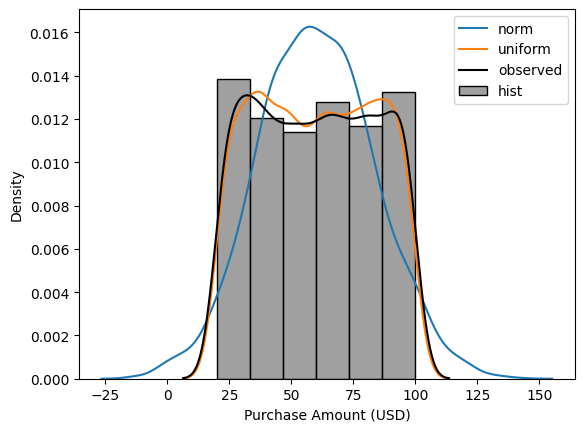

Review Rating
{'uniform': np.float64(0.004431484559908104), 'normal': np.float64(1.0096675513867286e-19)}


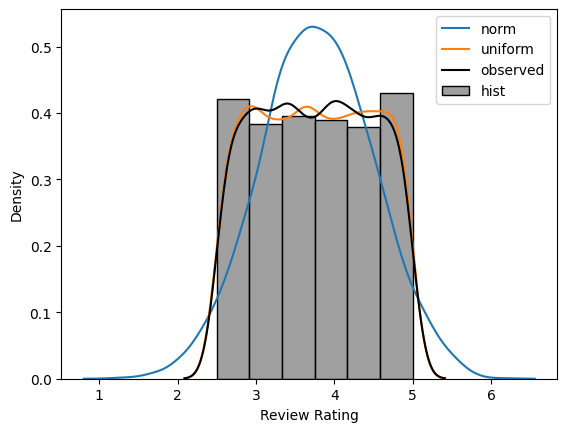

Previous Purchases
{'uniform': np.float64(0.002794876089588191), 'normal': np.float64(6.075338472597765e-16)}


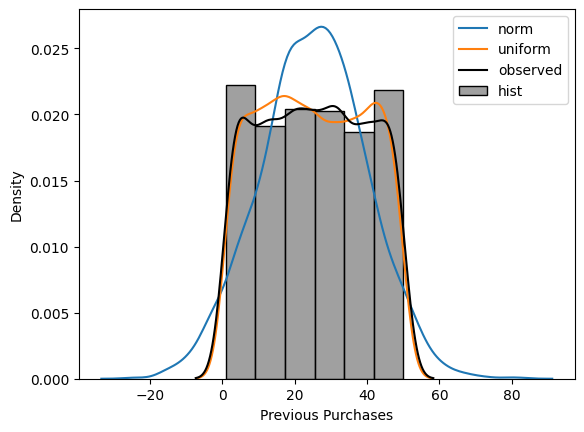

In [ ]:
#use column_makeup() and filtered_makeup() with these
# plot multiple brobablistic models from bellow onto observed
# return chi p_values and kstest p values  
# return skew and curtosis  
for col in ['Purchase Amount (USD)','Review Rating','Previous Purchases']:
    d_analyzer=DistributionAnalysis()
    vector=df[col].sort_values()
    d_analyzer.fit(vector)
    print(col)
    print(d_analyzer.test_vector_shape_kstest(df[col],distributions=['uniform','normal']))

    normalized=d_analyzer.normally_distributed_vector()
    uniform=d_analyzer.uniformlly_distributed_vector()
    fig, ax = plt.subplots()

    sns.histplot(vector,label='hist',ax=ax,stat='density', color='gray', bins=26, kde=False)
    sns.kdeplot(normalized,label='norm',ax=ax)
    sns.kdeplot(uniform,label='uniform',ax=ax)
    sns.kdeplot(vector,label='observed',color='black',ax=ax)
    plt.legend()
    plt.show()

# ============================================================================================
# ANOVA class
# ============================================================================================ 


"""
these use         
    half_combos=[[i.numeric_2,i.numeric_1] for i in num_data[['numeric_1','numeric_2']].itertuples()]
        repeated=[]
        for i in num_data[['numeric_1','numeric_2']].itertuples():
            if [i.numeric_1,i.numeric_2] in half_combos:
                if [i.numeric_2,i.numeric_1] not in repeated:
                    repeated.append([i.numeric_1,i.numeric_2])
        repeated = set(tuple(pair) for pair in repeated)
        mask = num_data.apply(lambda row: (row['numeric_1'], row['numeric_2']) not in repeated, axis=1)
        num_data = num_data.loc[mask]

        in three*2=6 places, but it can be faster with a groupby index that is merged onto with a concatinated df of pd.concat([df[col1,col2],df[col2,col1]])
        """


In [ ]:
import scipy.stats
import warnings
#these use f.survival_function or t.survival_function) to calculate the p value
# scipy.stats.f.sf(f_score,dfn,dfd) where dfn is the numerator--mean_square(ie variance) and dfd is denominator-->error# this returns a p value for the f stat
#     #https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html#scipy.stats.t
#     #https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html#scipy.stats.f


class ANOVA:
    def __init(self):
        self.two_way_interaction_columns=None
        self.two_way_interaction_sizes=None
        self.one_way_df_ANOVA_overview=None
        self.one_way_kruskal_wallis_df_overview=None

    # =========================================================================================================================================================================

    # ========================================================================================================================================================================= 

    # PREPROCESS
    # for uniform 2-way-ANOVA interaction sizes
    # presently stratification is not supported, stochastic under/over sampling is. 
    # In future versions, stratifications can be achieved with pd.sample(weights=) fitted based on bins&Probabilities
    # https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html
    def create_uniform_interactions(self, xx_y_prep_df,min_size=5, override_min=False, ntile=None):
        """
        override_min will sample with replacement from small datasets
        if ntile is not none, the interseciton size will be the ntile of sizes that are greater than min, otherwise smallest acceptable interaciton's size will be used

        """
        three_col_XX_y=pd.DataFrame(xx_y_prep_df.copy())  #ensure CuDF if applicable. A check would be better, but this prototypes well
        cols=three_col_XX_y.columns
        x1 = cols[0]
        x2 = cols[1]
        y = cols[2]

        #unique values for interactions
        x1_vars=three_col_XX_y[x1].unique()
        x2_vars=three_col_XX_y[x2].unique()

        #record interactions and sizes
        grouped=three_col_XX_y.groupby([x1,x2],as_index=False,observed=False)[y].agg('size')
        sufficient=grouped.loc[(grouped['size']>=min_size)]
        sizes=sufficient['size'].to_list()
        interactions=list(sufficient[[x1,x2]].itertuples(index=False,name=None))
        too_small_interactions=list(grouped.loc[(grouped['size']>0)&(grouped['size']<min_size)][[x1,x2]].itertuples(index=False,name=None))
        non_interactions=list(grouped.loc[(grouped['size']<=0)][[x1,x2]].itertuples(index=False,name=None))

        # concatinate a new dataframe with uniform interaction sizes
        result=[]
        if ntile is not None:
            n_rows=np.percentile(sizes,[ntile])[0].astype(int)
            #
            #warning
            for interaction in interactions:
                data=three_col_XX_y.loc[(three_col_XX_y[x1]==interaction[0])&(three_col_XX_y[x2]==interaction[1])].sample(n_rows)
                result.append(data)
            if override_min==True:
                #
                #warning
                for interaction in too_small_interactions:
                    data=three_col_XX_y.loc[(three_col_XX_y[x1]==interaction[0])&(three_col_XX_y[x2]==interaction[1])].sample(n_rows)
                    result.append(data)
        elif ntile is None:
            n_rows=min(sizes)
            for interaction in interactions:
                data=three_col_XX_y.loc[(three_col_XX_y[x1]==interaction[0])&(three_col_XX_y[x2]==interaction[1])].sample(n_rows)
                result.append(data)
            if override_min==True:
                #
                #warning
                for interaction in too_small_interactions:
                    data=three_col_XX_y.loc[(three_col_XX_y[x1]==interaction[0])&(three_col_XX_y[x2]==interaction[1])].sample(n_rows)
                    result.append(data)
        if override_min==True:
            interactions=interactions+too_small_interactions
            too_small_interactions=[]
        
        #metrics
        self.two_way_interaction_sizes=grouped
        #over_under_samplimng_interaciton_size=n_rows # not stratified, but random sampling
        self.two_way_interaction_columns={'interactions':interactions,'insufficient':too_small_interactions,'non_interactive': non_interactions }
        return pd.concat(result)
       
    # =========================================================================================================================================================================

    # =========================================================================================================================================================================     
            
    # 2 way ANOVA
    # uses typ2 1 sum or sqares,, the statsmodels implementation: two_way_ANOVA_for_un_balanced_data() adjusts for type 1,2,or 3 and is not optimized for GPU

    def two_way_ANOVA(self,three_col_XX_y,unbalanced_interaction_sizes=True,verbose=True):
        """
        Where col in positions [:2] are catigorical and [2] is numeric
        data is preprocessed to have uniform observations counts across interaction
        """
        three_col_XX_y=pd.DataFrame(three_col_XX_y.copy())  #ensure CuDF if applicable. A check would be better, but this prototypes well
        cols=three_col_XX_y.columns
        a = cols[0]
        b = cols[1]
        y = cols[2]

        #create an interaction dataframe (tempararily keep non interaction groups)
        interaction = three_col_XX_y.groupby([a,b],as_index=False,observed=False)[y].agg(['mean','size'])

        # track interacting and non interacting factors
        interaction_factors=list(interaction.loc[interaction['size']>=5][[a,b]].itertuples(index=False,name=None))
        non_interacting_factors=list(interaction.loc[interaction['size']<5][[a,b]].itertuples(index=False,name=None))
        if verbose:
            print(f"Interacting factors: {interaction_factors}\nNon interacting and count < 5 interaction factors: {non_interacting_factors}")

        # filter out non interaction factor groups
        interaction=interaction.loc[interaction['size']>0]

        if not unbalanced_interaction_sizes:
            nij=interaction['size'].mean()# this is okay because this is not a wieghted anova

        if not unbalanced_interaction_sizes:
            pass
            #assert ... f""
        if unbalanced_interaction_sizes==True:
            pass
            #assert

        #number of groups in a and in b
        a_number_of_groups = three_col_XX_y[a].nunique()
        b_number_of_groups = three_col_XX_y[b].nunique()

        #multiply num of groups by num_interact_ai_and_bj for groups in a & b
        if not unbalanced_interaction_sizes: 
            nij_multiply_a = nij*a_number_of_groups
            nif_multiply_b = nij*b_number_of_groups
        elif unbalanced_interaction_sizes==True:
            interaction['nij_product_a']=interaction['size']*a_number_of_groups
            interaction['nij_product_b']=interaction['size']*b_number_of_groups

        #grand mean
        overall_mean = three_col_XX_y[y].mean()

        #calculate sums of squares for t and e
        SST=((three_col_XX_y[y] - overall_mean)**2).sum()
        ### while broadcast subraction is unsuported, this merge is used as a middle step
        SSE_dataframe = three_col_XX_y.merge(interaction[[a,b,'mean']],on=[a,b],how='left',validate='m:1')
        SSE = ((SSE_dataframe[y]-SSE_dataframe['mean'])**2).sum()
        del SSE_dataframe

        #calculate sums of squares for groups of factors a & b
        if not unbalanced_interaction_sizes:
            mean_y_ai = three_col_XX_y.groupby(a,observed=True)[y].mean()#--------------------------------i changed observed to True in both of these
            interaction=interaction.merge(mean_y_ai.rename('mean_a'),left_on=a,right_index=True)
            SSA = ((mean_y_ai-overall_mean)**2).sum() * nif_multiply_b  # nb * a sum of centered squares 
            mean_y_bj = three_col_XX_y.groupby(b,observed=True)[y].mean()
            interaction=interaction.merge(mean_y_bj.rename('mean_b'),left_on=b,right_index=True)
            SSB = ((mean_y_bj-overall_mean)**2).sum() * nij_multiply_a  # na * b sum of centered squares
        if unbalanced_interaction_sizes==True:
            mean_and_count_y_ai = three_col_XX_y.groupby(a, observed=True)[y].agg(['mean','size'])
            mean_and_count_y_ai.columns=['mean_a','size_a']
            SSA = ((mean_and_count_y_ai['mean_a'] - overall_mean)**2 * mean_and_count_y_ai['size_a']).sum()
            mean_and_count_y_bj = three_col_XX_y.groupby(b, observed=True)[y].agg(['mean','size'])
            mean_and_count_y_bj.columns=['mean_b','size_b']
            SSB = ((mean_and_count_y_bj['mean_b'] - overall_mean)**2 * mean_and_count_y_bj['size_b']).sum()

        # sum of squares for interaction between a & b    
        if not unbalanced_interaction_sizes:
            SSAB = ((interaction['mean'] - interaction['mean_a'] - interaction['mean_b'] + overall_mean)**2).sum() * nij
        if unbalanced_interaction_sizes==True:
            interaction=interaction.merge(mean_and_count_y_ai['mean_a'],left_on=a,right_index=True)
            interaction=interaction.merge(mean_and_count_y_bj['mean_b'],left_on=b,right_index=True)
            SSAB = ((interaction['mean'] - interaction['mean_a'] - interaction['mean_b'] + overall_mean)**2 * interaction['size']).sum()

        if verbose==True:  
            print(f"SST = SSA+SSB+SSAB+SSE: {SST == SSA+SSB+SSAB+SSE}\nnp.isclose(SST, SSA+SSB+SSAB+SSE): {np.isclose(SST, SSA+SSB+SSAB+SSE)}")
            print("SST:", SST)
            print("SSA + SSB + SSAB + SSE:", SSA + SSB + SSAB + SSE)
            print("Residual:", SST - (SSA + SSB + SSAB + SSE))
            print("If the residual error is large, try another model \none_way_kruskal_wallis(), which is non-parametric\ntwo_way_ANOVA_for_un_balanced_data(), which implements statsmodels.api\nor over/under sample the data.") 
        # degrees of freedom
        dof_a, dof_b, dof_ab, dof_e = a_number_of_groups-1, b_number_of_groups-1, (a_number_of_groups-1)*(b_number_of_groups-1), three_col_XX_y.shape[0]-(a_number_of_groups * b_number_of_groups)
        # mean squares
        MSA,MSB,MSAB,MSE =  SSA/dof_a, SSB/dof_b, SSAB/dof_ab, SSE/dof_e
        # F-statistics 
        FA,FB,FAB = MSA/MSE, MSB/MSE, MSAB/MSE
        # p values
        p_value_A, p_value_B, p_value_AB = scipy.stats.f.sf(FA,dof_a,dof_e), f.sf(FB,dof_b,dof_e), f.sf(FAB,dof_ab,dof_e)

        res= {a:p_value_A,b:p_value_B,'interaction':p_value_AB}
        return res
    
    # =========================================================================================================================================================================

    # ========================================================================================================================================================================= 

    def one_way_ANOVA(self,two_col_df_x_y):
        """
        Where col in position [0] is catigorical and [1] is numeric
        """
        two_col_df_x_y=pd.DataFrame(two_col_df_x_y) 
        cols=two_col_df_x_y.columns
        x= cols[0]
        y= cols[1]
        number_of_groups=two_col_df_x_y[x].nunique()
        overall_mean=two_col_df_x_y[y].mean()

        #Sum of Squares Between
        SB_df=two_col_df_x_y.groupby(x,observed=True)[y].agg(['size','mean'])
        SSB=(((SB_df['mean']-overall_mean)**2)*SB_df['size']).sum()

        #Sum of Squares Within
        #untill broadcast level is supported @ https://docs.rapids.ai/api/cudf/stable/user_guide/api_docs/api/cudf.dataframe.subtract/#cudf.DataFrame.subtract
        #join is used instead of direct subtraction
        #map might be faster on smaller datasets than join
        SW_df=two_col_df_x_y.join(SB_df,on=x,validate='m:1')
        SW_df['observed-group_mean']=SW_df[y]-SW_df['mean']
        SW_df['observed-group_mean']=SW_df['observed-group_mean']**2
        SW_df=SW_df.groupby(x,observed=True)['observed-group_mean'].sum()
        #SW_df=SW_df**2
        SSW=SW_df.sum()
        del SW_df, SB_df

        #Degrees of Freedom
        dof_W=two_col_df_x_y.shape[0] - number_of_groups
        dof_B=number_of_groups - 1

        #Mean Squares
        MSB=SSB/dof_B
        MSW=SSW/dof_W

        #F-statistic
        f_statistic = MSB/MSW 

        #P_value      https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html#scipy.stats.f
        p_value = scipy.stats.f.sf(f_statistic,dof_B,dof_W)

        return p_value

    def test_all_cat_num_ANOVA(self,data,numeric_columns=None,categoric_columns=None):
        """
        
        """
        # Where x is categorical and y is nuneric
        # x columns
        if categoric_columns is None: 
            categoric_columns=list(set(list(data.select_dtypes('object').columns)+list(data.select_dtypes('category').columns)))

        # y columns
        if numeric_columns is None:
            numeric_columns=list(data.select_dtypes('number').columns)

        combinations=[(cat_col,num_col) for num_col in numeric_columns for cat_col in categoric_columns]
        res_dict={}
        for combo in combinations:
            p=self.one_way_ANOVA(data[[*combo]])
            res_dict[(combo[0],combo[1])]=[p]
        res = pd.DataFrame(res_dict).T.reset_index(drop=False)
        res.columns=['category','numeric','P-value']
        self.one_way_df_ANOVA_overview=res
        return res
        
    def cat_num_column_ANOVA_relationships(self,data, alpha=0.05,keep_similar=False, numeric_columns:list=None,categoric_columns:list=None):
        """
        takes alpha as a parameter 
        if reject is True, observations with p_values<alpha are returned
        """
        p_table=self.test_all_cat_num_ANOVA(data,numeric_columns,categoric_columns)
        if reject==False:
            return p_table.loc[p_table['P-value']>=alpha].reset_index(drop=True)
        return p_table.loc[p_table['P-value']<alpha].reset_index(drop=True)
    

    # =========================================================================================================================================================================

    # ========================================================================================================================================================================= 

    def two_sample_t_tests(self,catx_numy_df):

        """
        ***Warning, col1 to col2 is gets repeated as col2 to col1. Hence, there are a few excess combinations if filter_duplicates is False
        ***by default filtering is done downsream after dimensionality is reduced, but can be done here by setting filter_duplicates=True
        ***Suggestion is to remove duplicates after filtering values because it won't be vectorized, hence slowish
        Default is "welch's" t_test because it is robust to unequal varaince and unequal sample sizes

        "just always use Welch’s t-test, so that you don’t have to make any assumptions about equal variances." (https://www.statology.org/welchs-t-test/)

        """

        data=pd.DataFrame(catx_numy_df)
        cols=data.columns
        cat=cols[0]
        num=cols[1]
        df1=data.groupby(cat,as_index=False,observed=True)[num].agg(['mean','std','size'])
        nandf=df1.loc[(df1['size'] <= 1) & (df1['std'] <= 0)]
        nandf['subcat_1'],nandf['subcat_2'],nandf['P-value'],nandf['n_samples_1'],nandf['n_samples_2'] = nandf[cat], np.nan, np.nan, nandf['size'], np.nan
        nandf=nandf[['subcat_1','subcat_2','P-value','n_samples_1','n_samples_2']]
        df1 = df1.loc[(df1['size'] > 1) & (df1['std'] > 0)]
        df1=df1.reset_index(drop=True)
        combos = list(combinations(df1[cat].unique(), 2))
        merged=pd.DataFrame(combos,columns=['subcat_1','subcat_2'])
        merged=merged.merge(df1,how='left',right_on=cat,left_on='subcat_1')
        merged=merged.merge(df1,how='left',right_on=cat,left_on='subcat_2',suffixes=('1','2'))
        merged['std1']=merged['std1']**2
        merged['std2']=merged['std2']**2
        merged['t_score']= (merged['mean1']-merged['mean2']) /  np.sqrt( (merged['std1']/merged['size1'])+(merged['std2']/merged['size2']) )
        merged['dof']= ( (merged['std1']/merged['size1'])+(merged['std2']/merged['size2']) )**2 / ( ((merged['std1']/merged['size1'])**2 / (merged['size1']-1)) +((merged['std2']/merged['size2'])**2 / (merged['size2']-1)) )
        merged['P-value'] = 2 * scipy.stats.t.sf( np.abs(merged['t_score']),  merged['dof']  )
        merged=merged.rename(columns={'size1':'n_samples_1','size2':'n_samples_2'})
        merged=pd.concat([merged[['subcat_1','subcat_2','P-value','n_samples_1','n_samples_2']],nandf])
        return merged

    def subcategory_similarities(self,catx_numy_df,alpha=0.05,return_similar=False,min_observations:int=None):
        data=self.two_sample_t_tests(catx_numy_df)
        data=data.dropna(subset=['subcat_2'])
        if return_similar==False:
            data=data.loc[data['P-value']<alpha]
        if min_observations is not None:
            data=data.loc[(data['n_samples_1']>min_observations)&(data['n_samples_2']>min_observations)]
        data=data.reset_index(drop=True)
        return data

    # =========================================================================================================================================================================
    #ONE WAY KRUSKUL WALLIS TEST, similar to a onw way ANOVA but the assumptions make it more robust to non-normally distributed data
    #https://library.virginia.edu/data/articles/getting-started-with-the-kruskal-wallis-test
    #H = (12 / N(N + 1)) / sum(Ri² / ni) - 3(N + 1)
    # assumptions 1) all groups have the same distribution (else larger sample size), more groups require larger sample sizes, 
    # ========================================================================================================================================================================= 

    def one_way_kruskal_wallis(self,two_col_cat_num_df):
        """
        Where col in positions [0] is catigorical and [1] is numeric
        """
        
        data=pd.DataFrame(two_col_cat_num_df.copy())  #ensure CuDF if applicable. A check would be better, but this prototypes well
        data.columns=[f"temp_{(i+1)*10}" for i in range(len(data.columns))]
        cols=data.columns
        x = cols[0]
        y = cols[1]
        #assign ranks
        data['rank']=data[y].rank(method='average')
        #   where ni is each group size
        # and Ri is sum of ranks for group i
        grouped_data=data.groupby(x,observed=True)['rank'].agg(['sum','size'])
        #where k is number of groups and N is total observations
        k=grouped_data.shape[0]
        N=data.shape[0]
        #print(f"(12/(N*(N+1))): {(12/(N*(N+1)))}, ((grouped_data['sum']**2)/grouped_data['size']) {((grouped_data['sum']**2)/grouped_data['size'])}, (3*(N+1)) {(3*(N+1))}, np.sum(  ((grouped_data['sum']**2)/grouped_data['size']) - (3*(N+1))  ) {(  np.sum((grouped_data['sum']**2)/grouped_data['size']) - (3*(N+1))  )}")
        h_statistic =  (12/(N*(N+1)))   *  np.sum(  ((grouped_data['sum']**2)/grouped_data['size'])) - (3*(N+1))  
        dof = k-1
        p_value = scipy.stats.chi2.sf(h_statistic, dof)
        return p_value
    
    def test_all_cat_num_kruskal_wallis(self,data,numeric_columns=None,categoric_columns=None):
        """
        
        """
        # Where x is categorical and y is nuneric
        # x columns
        if categoric_columns is None: 
            categoric_columns=list(set(list(data.select_dtypes('object').columns)+list(data.select_dtypes('category').columns)))

        # y columns
        if numeric_columns is None:
            numeric_columns=list(data.select_dtypes('number').columns)

        combinations=[(cat_col,num_col) for num_col in numeric_columns for cat_col in categoric_columns]
        res_dict={}
        for combo in combinations:
            p=self.one_way_kruskal_wallis(data[[*combo]])
            res_dict[(combo[0],combo[1])]=[p]
        res = pd.DataFrame(res_dict).T.reset_index(drop=False)
        res.columns=['category','numeric','P-value']
        self.one_way_kruskal_wallis_df_overview=res
        return res

    def cat_num_column_kruskal_wallis_relationships(self,data, alpha=0.05,reject=True, numeric_columns:list=None,categoric_columns:list=None):
        """
        takes alpha as a parameter 
        if reject is True, observations with p_values<alpha are returned
        """
        p_table=self.test_all_cat_num_kruskal_wallis(data,numeric_columns,categoric_columns)
        if reject==False:
            return p_table.loc[p_table['P-value']>=alpha].reset_index(drop=True)
        return p_table.loc[p_table['P-value']<alpha].reset_index(drop=True)

    #=========================================================================================================================================================
    #=========================================================================================================================================================
    # test one cat col to rest
  
  



    # test on num col to rest    

,col1,col2
0,r,t
1,r,y
2,r,w
3,t,y
4,t,w
5,y,w




"""


need a 2 way to test variance within a cat to num col relationship  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.levene.html  
from scipy.stats import levene

# Sample data
group1 = [7, 14, 14, 13, 12, 9, 6, 14, 12, 8]
group2 = [15, 17, 13, 15, 15, 13, 9, 12, 10, 8]
group3 = [6, 8, 8, 9, 5, 14, 13, 8, 10, 9]

# Perform Levene's test
statistic, p_value = levene(group1, group2, group3)

print("Levene's test statistic:", statistic)
print("p-value:", p_value)

"""

In [19]:
# there should be more consideration of linarity and other assumptions.
# perhaps usea call to identify the distribution and raise warnings or suggestions
# study the assumptions of spearmans and kendall's
# ACTION NOT NESCESSARY AS OF YET
class PearsonCoefficient:
    def __init__(self):
        self.one_way_pearson_coefficient_overview=None

    def test_all_num_num_pearson_coefficient(self,data,self_detect:bool=True,numeric_columns:list=None,pseudo_numeric_columns:list=None,filter_duplicates=False):
        """
        ***Warning, col1 to col2 is gets repeated as col2 to col1. Hence, there are a 2 times combinations if filter_duplicates is False
        ***by default filtering is done downsream after dimensionality is reduced, but can be done here by setting filter_duplicates=True
        ***Suggestion is to remove duplicates after filtering values because it won't be vectorized, hence slowish
        Where pseudo_numeric can be numeric labeled data
        """
        columns=[]
        if numeric_columns is None and pseudo_numeric_columns is None: 
            columns=list(data.select_dtypes('number').columns)
        if numeric_columns is not None:
            columns+=numeric_columns
        if pseudo_numeric_columns is not None:
            columns+=pseudo_numeric_columns
        if self_detect==True:
            columns+=list(data.select_dtypes('number').columns)
        columns=list(set(columns))
        num_data=pd.DataFrame(data.copy())
        num_data=num_data[columns].corr().unstack().reset_index(drop=False).rename(columns={'level_0':'numeric_1','level_1':'numeric_2',0:'Correlation'})
        mask=num_data['numeric_1']!=num_data['numeric_2']
        num_data = num_data.loc[mask]
        if filter_duplicates==True:
            half_combos=[[i.numeric_2,i.numeric_1] for i in num_data[['numeric_1','numeric_2']].itertuples()]
            repeated=[]
            for i in num_data[['numeric_1','numeric_2']].itertuples():
                if [i.numeric_1,i.numeric_2] in half_combos:
                    if [i.numeric_2,i.numeric_1] not in repeated:
                        repeated.append([i.numeric_1,i.numeric_2])
            repeated = set(tuple(pair) for pair in repeated)
            mask = num_data.apply(lambda row: (row['numeric_1'], row['numeric_2']) not in repeated, axis=1)
            num_data = num_data.loc[mask]
        self.one_way_pearson_coefficient_overview=num_data
        return num_data
    
    
    def num_num_column_pearson_coefficient_relationships(self,data, corr=0.6,reject=True,self_detect:bool=True,numeric_columns:list=None,pseudo_numeric_columns:list=None):
        """
        takes corr as a parameter 
        if reject is True, observations with correlations >= corr are returned.
        """
        num_data=self.test_all_num_num_pearson_coefficient(data,self_detect,numeric_columns,pseudo_numeric_columns)
        if reject==False:
            num_data=num_data.loc[num_data['Correlation']>=np.abs(corr)].reset_index(drop=True)
        else: num_data = num_data.loc[num_data['Correlation']<np.abs(corr)].reset_index(drop=True)
        half_combos=[[i.numeric_2,i.numeric_1] for i in num_data[['numeric_1','numeric_2']].itertuples()]
        repeated=[]
        for i in num_data[['numeric_1','numeric_2']].itertuples():
            if [i.numeric_1,i.numeric_2] in half_combos:
                if [i.numeric_2,i.numeric_1] not in repeated:
                    repeated.append([i.numeric_1,i.numeric_2])
        repeated = set(tuple(pair) for pair in repeated)
        mask = num_data.apply(lambda row: (row['numeric_1'], row['numeric_2']) not in repeated, axis=1)
        num_data = num_data.loc[mask]
        return num_data

In [ ]:
### THIS COULD HAVE AN NTILE BINNER AND EVEN A NORMALIZER BINNER -calculate granularity of a perfecctly normal gaussian pdf and cdf  [such as to compare similar to a parreto, but as an area plot of proffit overlaying sales]
### 

import warnings

class Bin(ANOVA, PearsonCoefficient):#, Chi2):
    def __init__(self):
        self.numeric_target_column_minimums=None
        self.numeric_feature_col_thresholds=None

    # a helper function that bins columns
    def binner(self,x,num_bins):
        """
        used 2x in Bin().
        """
        mn,mx=x.min(),x.max()
        bins=np.linspace(mn-1e-10,mx+1e-10,num_bins+1,endpoint=True)
        return np.digitize(x.copy(), bins, right=False)
    
    #=============================================================================================================================================================
    # a helper functions and an endpoint function that takes columns as input, and return data that explains at what number of bins in a numeric column influences significance
    # of column relationships
    #=============================================================================================================================================================
    #examine  relationships prior to binning
    def pre_bin_relationships(self,df,cat_num_alpha:float=0.05,num_num_corr:float=0.6,numeric_columns=None,categoric_columns=None): 
        """
        prepares data for Bin().pair_column_headers()
        """
        cat_num_df=self.cat_num_column_kruskal_wallis_relationships(df, alpha=cat_num_alpha,reject=True, numeric_columns=numeric_columns,categoric_columns=categoric_columns)
        num_num_df=self.num_num_column_pearson_coefficient_relationships(df, corr=num_num_corr,reject=False,self_detect=False,numeric_columns=numeric_columns)
        return num_num_df,cat_num_df
    def pair_column_headers(self,num_num_df,cat_num_df):
        """
        processes output from Bin().pre_bin_relationships()
        prepares data for Bin().determine_min_number_of_bins()
        if either arg is entered as None, it returns None for that arg
        """
        if cat_num_pairs is not None:
            cat_num_pairs=tuple((i.category,i.numeric) for i in cat_num_df[['category','numeric']].itertuples())
        if num_num_pairs is not None:
            num_num_pairs=tuple([(i.numeric_1,i.numeric_2) for i in num_num_df[['numeric_1','numeric_2']].itertuples()]+[(i.numeric_2,i.numeric_1)  for i in num_num_df[['numeric_1','numeric_2']].itertuples()])
        return num_num_pairs, cat_num_pairs


    def get_abs_coefficient_stat(self,data):
        """
        a function used in Bin().determine_min_number_of_bins()
        and passed to Bin().find_min_bins()

        """
        xcol,ycol=data.columns[0],data.columns[1]
        return np.abs(data[ycol].corr(data[xcol]))



    def find_min_bins(self, data, y_col, x_columns, test_func, threshold, direction_of_relationship):
        """
        direction_of_relationship='lower'|'greater' indicates area where bins are still related to other columns
        returns: 
            cols_min_max_and_stat={
                            'column_i': 
                                    {'min_w_relationship':int or None,
                                    'max_w_no_relationship':int or None,
                                    'threshold_stat':np.float64() or None}, 
                            'column_i':...}
            global_min_for_these_columns:int
        accepts test_func as arg. it can be self(ANOVA).one_way_kruskal_wallis(self,two_col_cat_num_df) or self.get_abs_coefficient_stat(self,data)
        """
        mins_for_each_col=[]
        cols_min_max_and_stat={}
        for col in x_columns:
            lowest_possible_bins,highest_possible_bins=1,data.shape[0]
            low=lowest_possible_bins
            high=highest_possible_bins
            min_relation_max_no_relation_stat=[None,None,None]
            while low<=high:
                mid=(low+high)//2
                data['binned']=self.binner(data[y_col],mid)
                stat = test_func(data[[col,'binned']])
                
                #print(f"bin: {mid}      stat: {stat}      threshold: {threshold}")
                
                if direction_of_relationship=='lower':
                    if stat>=threshold:
                        min_relation_max_no_relation_stat[1]=mid
                        low=mid+1
                    else:
                        min_relation_max_no_relation_stat[0]=mid
                        min_relation_max_no_relation_stat[2]=stat
                        high=mid-1

                elif direction_of_relationship=='greater':
                    if stat<threshold:
                        min_relation_max_no_relation_stat[1]=mid
                        low=mid+1
                    else:
                        min_relation_max_no_relation_stat[0]=mid
                        min_relation_max_no_relation_stat[2]=stat
                        high=mid-1
            
            if min_relation_max_no_relation_stat[0]!=None:
                mins_for_each_col.append(min_relation_max_no_relation_stat[1])
            cols_min_max_and_stat[col]={'min_w_relationship':min_relation_max_no_relation_stat[0],'max_w_no_relationship':min_relation_max_no_relation_stat[1],'threshold_stat':min_relation_max_no_relation_stat[2]}
        global_min_for_these_columns=min(mins_for_each_col)
        return global_min_for_these_columns , cols_min_max_and_stat




    def determine_min_number_of_bins(self,dataframe,num_num_pairs,cat_num_pairs,min_coeff=0.6,max_p_value=0.05):
        """
        takes output of Bin().pair_column_headers() as input
        shares alphas with Bin().pre_bin_relationships()
        uses self.find_min_bins() and binner() internally
        outputs: 
        result metrics = {'target column i': 
                                min_bins_that_maintain_global_relationships,
                        'target column n':.................}
        x_col_thresholds = {'feature column i': 
                                {'xi column_threshold': (min num bins with relationship,  
                                                        max num bins with no relationship, 
                                                        np.float64(coeff or p_value w/relationship))},
                            'feature column n':..........}
        """
        data=dataframe.copy()
        #extract the columns that will be y-target
        cols_to_bin=list(set([i[1] for i in cat_num_pairs]+[i[1] for i in num_num_pairs]))  #use index 1 for both 
        #track minumum bins and max,no-relationship bins
        minimums={}
        y_relation_to_x_col_thresholds={}
        #iterate through target-numeric columns
        for col in cols_to_bin:
            #extract the columns that will be x-features
            x_cat_columns=tuple(set(i[0] for i in cat_num_pairs if i[1]==col))
            x_num_columns=tuple(set(i[0] for i in num_num_pairs if i[1]==col))

            # make calls to func min bins and metrics
            if len(x_cat_columns)>0:
                min_number_of_bins_categorical,column_binning_metrics_categorical=self.find_min_bins( data, col, x_cat_columns, self.one_way_kruskal_wallis, max_p_value, direction_of_relationship='lower')
            if len(x_num_columns)>0:
                min_number_of_bins_numerical,column_binning_metrics_numerical=self.find_min_bins( data, col, x_num_columns, self.get_abs_coefficient_stat, min_coeff, direction_of_relationship='greater')
            if len(x_num_columns)<1 and len(x_cat_columns)<1:
                warnings.warn(f"For {col}, There are no potential solutions at these thresholds.", UserWarning)
                continue
            #update threshold metrics
            elif len(x_num_columns)>0 and len(x_cat_columns)>0:
                column_metrics=column_binning_metrics_categorical | column_binning_metrics_numerical
                y_relation_to_x_col_thresholds[col]=column_metrics
                #update the minimum bin that retains   ALL tested relationships
                if min_number_of_bins_categorical is None and min_number_of_bins_numerical is None:
                    minimum = None
                elif min_number_of_bins_categorical is None:
                    minimum = min_number_of_bins_numerical
                elif min_number_of_bins_numerical is None:
                    minimum = min_number_of_bins_categorical
                else:
                    minimum = min(min_number_of_bins_numerical,min_number_of_bins_categorical)
                minimums[col]=minimum
            elif len(x_num_columns)>0 and len(x_cat_columns)<1:
                y_relation_to_x_col_thresholds[col]=column_binning_metrics_numerical
                #update the minimum bin that retains   ALL tested relationships
                if min_number_of_bins_numerical is None:
                    minimum = None
                else:
                    minimum = min_number_of_bins_numerical
                minimums[col]=minimum
            elif len(x_num_columns)<1 and len(x_cat_columns)>0:
                y_relation_to_x_col_thresholds[col]=column_binning_metrics_categorical
                #update the minimum bin that retains   ALL tested relationships
                if min_number_of_bins_categorical is None:
                    minimum = None
                else:
                    minimum = min_number_of_bins_categorical
                minimums[col]=minimum
        return minimums, y_relation_to_x_col_thresholds



    #=============================================================================================================================================================
    #this needs edge case when xfeature columns is none and/or ytarget columns is none, presently, it attempts to detect datatypes
    #needs to have a default max num bins, such as 30%
    #=============================================================================================================================================================

    
    def relational_binner(self,df,max_cat_to_numeric_p=0.05,min_coeff=0.6,numeric_columns=None,categoric_columns=None):
        """
        if numeric_columns or categorical_columns are left as None, they will be infered which can result in missing, or incorrect comparisons
        after calling this function, min bins ==> self.numeric_result_metrics[column]['min_bins']

        calling this function will initialize object attributes:
        self.numeric_min_bins = {
                        'numeric column 1': 
                                {'min_bins': min number of bins that maintain significant relationship with all other columns considered,
                                'global categorical column stat key': min number of bins that maintain significant relationship,  
                                'global numerical column stat key': min number of bins that maintain significant relationship
                                }, 
                        'numeric column 2':..........}
        and
        self.numeric_binning_metrics = {'numeric column': 
                                {'xi column_threshold': (max num bins with no relationship,min num bins with relationship, np.float64(coeff or p_value w/relationship))},
                            'numeric column 2':..........}

        """
        num_num_df,cat_num_df=self.pre_bin_relationships(df,cat_num_alpha=max_cat_to_numeric_p,num_num_corr=min_coeff,numeric_columns=numeric_columns,categoric_columns=categoric_columns)
        num_num_pairs, cat_num_pairs=self.pair_column_headers(num_num_df,cat_num_df)
        self.numeric_target_column_minimums, self.numeric_feature_col_thresholds = self.determine_min_number_of_bins(df,num_num_pairs,cat_num_pairs,min_coeff=min_coeff,max_p_value=max_cat_to_numeric_p)
  
    #=============================================================================================================================================================
    #=============================================================================================================================================================
    
    # a one to rest apprach via: self.find_min_bins(self, data, y_col, x_columns, test_func, threshold, direction_of_relationship)

chi test of independence  


> Need to write warnings and raise errors based on assumptions 

In [ ]:

#https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.chdtrc.html#scipy.special.chdtrc
# of note: scipy.special.chdtrc(dof,chi_stat) is optimized for jax, pytorch, and cupy-drop-in replacements  

import itertools
from itertools import combinations
from scipy import special
import warnings

class Chi2:
    def __init__(self):
        self.independence_overview=None
        self.good_of_fit=None

    def column_makeup(self,data,x1,x2):
        """
        accepts impute as arg1: a dataframe 
        arg2: list of column(s) to calculate the grouped count(s) and percentages of
        returns a dataframd with columns [arg2,count,pct_makeup]
        """
        columns=[x1,x2]
        func_df= data[columns].groupby(columns,as_index=False,observed=False).size().rename(columns={'size':'count'})
        total=func_df['count'].sum()
        func_df['pct_makeup']=func_df['count']/total         
        return func_df.sort_values(by=[i for i in columns]).reset_index(drop=True)
        
    def contingency_table(self,data,x_1,x_2,kind:str='joint_probability'):
        """
        input a dataframe, column_name_1:str, column_name_2'str, and kind = 'joint_probability | 'frequency' (defaults to joint_probability)  
        returns a contingency table
        BOTTOM AND LEFT COLUMNS CONTAINING MARGINAL VALUES  
        """
        base_quantity_table=self.column_makeup(data,x_1,x_2)
        value_col='pct_makeup' if kind=='joint_probability' else 'count'
        contingency_table=base_quantity_table.pivot(index=x_1,columns=x_2,values=value_col).reset_index(drop=False)
        del base_quantity_table
        contingency_table.columns.name=None
        contingency_table['right_margin'.upper()]=contingency_table.iloc[:,1:].sum(axis=1)
        contingency_table=pd.concat( [contingency_table, pd.Series(['bottom_margin'.upper()]+list(contingency_table.iloc[:,1:].sum(axis=0)),index=contingency_table.columns).to_frame().T   ]  )
        contingency_table=contingency_table.set_index(contingency_table.columns[0])
        return contingency_table

    #expected values
    def frequencies_table(self,data,x_1,x_2,kind:str='joint_probability'):
        """
        kind='frequency' for a frequency table
        """
        base_quantity_table=self.column_makeup(data,x_1,x_2)
        value_col='pct_makeup' if kind=='joint_probability' else 'count'
        frequencies_table=base_quantity_table.pivot(index=x_1,columns=x_2,values=value_col).reset_index(drop=False)
        del base_quantity_table
        frequencies_table=frequencies_table.set_index(frequencies_table.columns[0])
        return frequencies_table
        
    ## consider adding a flag if any cell has an expected value <
    def chi_squared_independence(self,data,x_1,x_2):     
        """
        test of independence
        """
        observed = self.frequencies_table(data, x_1, x_2, kind='frequency')
        expected = ( observed.sum(axis=1).to_numpy().reshape(-1,1)@observed.sum(axis=0).to_numpy().reshape(1,-1) ) / observed.sum().sum()
        chi_stat = (( (observed-expected)**2)/expected).sum().sum()
        dof      = (observed.shape[0]-1)*(observed.shape[1]-1)
        p_value  = scipy.special.chdtrc(dof,chi_stat)
        return p_value


    def test_all_cat_columns_chi_independence(self,data,columns=None,additional=True):
        """
        if columns == None, this defaults to detect 'object' and 'category' dtypes and won't see 'int'
        if columns != None, additional==True will add columns to the default, else additional=False will only consider columns included in the args
        """
        if columns is None:
            columns=list(set(list(data.select_dtypes('object').columns)+list(data.select_dtypes('category').columns)))
        elif additional is True and columns is not None: 
            columns=list(set(list(data.select_dtypes('object').columns) + list(data.select_dtypes('category').columns) + list(columns)))

        combinations=list(itertools.combinations(columns,2))
        res_dict={}
        for combo in combinations:
            p=self.chi_squared_independence(data,combo[0],combo[1])
            res_dict[(combo[0],combo[1])]=[p]
        res = pd.DataFrame(res_dict).T.reset_index(drop=False)
        res.columns=['category_a','category_b','P-value']
        self.independence_overview=res
        return res


    def categorical_column_relationships(self,data, alpha=0.05, columns=None, additional=True):
        """
        where additional true and colomns can overide default self detect
        such as:
        if columns == None, this defaults to detect 'object' and 'category' dtypes and won't see 'int'
        if columns != None, additional==True will add columns to the default, else additional=False will only consider columns included in the args
        """
        p_table=self.test_all_cat_columns_chi_independence(data,columns,additional)
        return p_table.loc[p_table['P-value']<alpha].reset_index(drop=True)


    #test for uniformness  
    ## consider adding a flag if any cell has an expected value <
    def chi_squared_goodness_of_fit(self,x,expected_probs=None):
            """
            accepts x as a panda series 
            if expected_probs is None, a uniform distribution is used as the epxpected
            otherwise, expected_probs should be a pd.Series() indexed or dict with the values as probs and index/key as the vriables compared to in observed
            """
            observed = pd.Series(x.value_counts().values,index=x.value_counts().index)
            if expected_probs is None:
                expected =[x.shape[0]/x.nunique()]*observed.shape[0]
                expected = np.array(expected)
            else:
                probs = pd.Series(expected_probs).reindex(observed.index, fill_value=0)
                if (probs < 0).any():
                    raise ValueError("Expected probabilities must be non-negative")
                expected = probs * observed.sum()
            if (expected < 5).any():
                raise ValueError("Chi-square assumption violated: expected counts < 5")
            
            chi_stat = (( (observed-expected)**2)/expected).sum()
            dof      = x.nunique()-1
            return scipy.special.chdtrc(dof, chi_stat)


    def test_all_cat_columns_chi_good_of_fit(self,data,columns=None,additional=True):
        """
        if columns == None, it defaults to detect 'object' and 'category' dtypes and won't see 'int', or 'datetime'
        if columns != None and additional==True all, 'object' and 'category' columns will still be included along with the columns
        if columns != None and additional==False, only columns included in the args will be included
        """
        if columns is None:
            columns=list(set(list(data.select_dtypes('object').columns)+list(data.select_dtypes('category').columns)))
        elif additional is True and columns is not None: 
            columns=list(set(list(data.select_dtypes('object').columns)+list(data.select_dtypes('category').columns)+list(columns)))

        res_dict={}
        for col in columns:
            p=self.chi_squared_goodness_of_fit(data[col])
            res_dict[col]=[p]
        res = pd.DataFrame(res_dict).T.reset_index(drop=False)
        res.columns=['category','P-value']
        self.good_of_fit=res
        return res

        
    def categorical_column_good_fit(self,data,alpha=0,is_uniform=True):
        """
        is_uniform specifies to return only results that meet is or isn't booleon criterion
        returns all cat columns by default. So dtype 'category', or 'object' must be assigned to the data.
        """
        p_table=self.test_all_cat_columns_chi_good_of_fit(data,additional=True)
        if is_uniform==False:
            return p_table.loc[p_table['P-value']<alpha].reset_index(drop=True)
        return p_table.loc[p_table['P-value']>=alpha].reset_index(drop=True)



    def chi2_homogeneity(self,x1,x2):
        """
        Chi-square test of homogeneity for two samples.
        to answer: “Do these two samples come from the same categorical distribution?”
        """
        x1 = pd.Series(x1).value_counts().to_frame('x1')
        x2 = pd.Series(x2).value_counts().to_frame('x2')
        observed=x1.merge(x2,how='outer',left_index=True,right_index=True)
        observed = observed.fillna(0)

        row_totals=observed.sum(axis=1)
        col_totals=observed.sum(axis=0)
        grand_total=row_totals.sum()
        expected = np.outer(row_totals, col_totals) / grand_total
        #expected = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
        low = expected < 5
        if low.sum() / expected.size > 0.2:
            warnings.warn("More than 20% of expected counts < 5")
            return np.nan
        """
        if (expected < 5).any().any():
            warnings.warn("Chi-square assumption violated: expected count < 5\nDefault: return NaN")
            return np.nan
        """
        chi_stat=(((observed.to_numpy()-expected)**2)/expected).sum().sum()
        dof      = (observed.shape[0]-1)*(observed.shape[1]-1)
        p_value  = scipy.special.chdtrc(dof,chi_stat)
        return p_value




    def chi_subcat_analysis(self,colx1_colx2_df):
        """
        takes two colomns and breaks down how subcategories within each compare
        it looks in both directions: 
        every combination of 2 subcats in colx1 are compared based on how they relate to colx2.
        and every subcat combination of 2 in colx2 are compared as well.
        """
        header_1, header_2 =colx1_colx2_df.columns[0],colx1_colx2_df.columns[1]
        colx1,colx2=colx1_colx2_df[header_1],colx1_colx2_df[header_2]
        #get all combinations for both columns apart from each other
        subcat_combos_in_1, subcat_combos_in_2 = list(itertools.combinations(list(set(colx1)),2)), list(itertools.combinations(list(set(colx2)),2))
        #built the base dataframe that will store P-values
        subcat_1_df=pd.DataFrame(subcat_combos_in_1,columns=['subcat_a','subcat_b'])
        subcat_1_df['source_column']=header_1
        subcat_2_df=pd.DataFrame(subcat_combos_in_2,columns=['subcat_a','subcat_b'])
        subcat_2_df['source_column']=header_2
        result_df=pd.concat([subcat_1_df,subcat_2_df])
        result_df['P-value']=np.nan
        #iterate through a loop that will check combination in both directions
        for i in range(max(len(subcat_combos_in_1),len(subcat_combos_in_2))):

            if i < len(subcat_combos_in_1):
                subcat_1a=colx1_colx2_df.loc[colx1_colx2_df[header_1]==subcat_combos_in_1[i][0]][header_2]
                subcat_1b=colx1_colx2_df.loc[colx1_colx2_df[header_1]==subcat_combos_in_1[i][1]][header_2]
                p_1=self.chi2_homogeneity(subcat_1a,subcat_1b)
                result_df.loc[(result_df['subcat_a']==subcat_combos_in_1[i][0])&(result_df['subcat_b']==subcat_combos_in_1[i][1])&(result_df['source_column']==header_1),'P-value']=p_1

            if i < len(subcat_combos_in_2):
                subcat_2a=colx1_colx2_df.loc[colx1_colx2_df[header_2]==subcat_combos_in_2[i][0]][header_1]
                subcat_2b=colx1_colx2_df.loc[colx1_colx2_df[header_2]==subcat_combos_in_2[i][1]][header_1]
                p_2=self.chi2_homogeneity(subcat_2a,subcat_2b)
                result_df.loc[(result_df['subcat_a']==subcat_combos_in_2[i][0])&(result_df['subcat_b']==subcat_combos_in_2[i][1])&(result_df['source_column']==header_2),'P-value']=p_2
        return result_df



    def subcategory_similarities(self,cat_cat_df,alpha=0.05,return_similar=False,drop_nans=True):
        """
        implements a chi**2 test of homogeneity between all subcat combinations in two columns both directions: colA->colB and colB->colA 
        returns a dataframe filtered by parameters: alpha=0.05,return_similar=False
        """
        data=self.chi_subcat_analysis(cat_cat_df)
        if drop_nans=True:
            data=data.dropna(subset=['P-value'])
        if return_similar==False:
            data=data.loc[data['P-value']<alpha]
        data=data.reset_index(drop=True)
        return data
    

    
        """
        Potential adds to homogeneity and independence tests:
        add Cramér’s V
        auto-collapse sparse categories
        generalize to k samples
        """

    #============================================================================================================================================================
    #============================================================================================================================================================


    def proportion_are_deterministic_subcats(self,df, super_col, sub_col):
        """
        return num_deterministic_subcats/num_non_deterministic_subcats
        takes a dataframe, a potential supercat, and a potential subcat
        """
        data = df[[super_col, sub_col]].copy()
        
        # Count how many unique supercategories each subcategory maps to
        mapping_counts = data.groupby(sub_col)[super_col].nunique()    
        # Deterministic check
        deterministic = (mapping_counts == 1).all()    
        # Proportion of subcategories that map to only one supercategory
        proportion_deterministic = (mapping_counts == 1).mean()
        return proportion_deterministic

    def evidence_is_supercat_given_subcat(self,df,supercat,subcat):
        """
        Measures uncertainty in `super_col` given `sub_col`
        where:
        0 bits -> perfect supercategory
        Higher values -> more ambiguity
        """
        # Conditional entropy H(super_col | sub_col)
        # https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html
        # so each row sums to 1: pd.crosstab(index,columns,rows/sum_rows)
        crosstab = pd.crosstab(df[subcat], df[supercat], normalize='index')
        # log 2 because we are expressing in bits for interpretability 
        # Shannon Entropy    
        bits = -(crosstab * np.log2(crosstab + 1e-12)).sum(axis=1).mean()
        return bits





    def map_subcat_to_supercat(self,df,supercat,subcat):
        """
        Returns a dataframe that maps to the most common supercategory for each subcategory.
        """
        data = df[[supercat, subcat]].copy()
        # Most common mapping for each subcategory
        mapping = data.groupby(subcat)[supercat].agg(lambda x: x.value_counts().idxmax()).sort_values(by=[supercat,subcat],ascending=[True,True]).reset_index(drop=True)
        return mapping
        


    def test_many_cats_for_deterministic_super_cats(self,df,columns:list):
        """
        takes a data frame and list of columns
        dataframe with columns 'supercategory', 'subcategory', 'proportion_true_subcategories'
        """
        data=df[columns].copy()
        if len(columns)<1:
            return None
        res=[]
        l,r=0,1
        while r<len(columns)-1:
            if data[columns[l]].nunique()>=data[columns[r]].nunique():
                arrangement=(columns[l],columns[r],self.proportion_are_deterministic_subcats(data,columns[l],columns[r]))
            else: arrangement=(columns[r],columns[l],self.proportion_are_deterministic_subcats(data,columns[r],columns[l]))
            res.append(arrangement)
            if r>=len(columns)-1:
                l+=1
                r=l+1
            else:
                r+=1
        return pd.DataFrame(res,columns=['supercategory', 'subcategory', 'proportion_are_true_subcategories'])


    def test_many_cats_for_evidence_of_super_cats(self,df,columns:list):
        """
        takes a data frame and list of columns
        evidence is not probabilistic
        dataframe with columns 'supercategory', 'subcategory', 'ShannonEntropyBits'
        """
        data=df[columns].copy()
        if len(columns)<1:
            return None
        res=[]
        l,r=0,1
        while r<len(columns)-1:
            if data[columns[l]].nunique()>=data[columns[r]].nunique():
                arrangement=(columns[l],columns[r],self.evidence_is_supercat_given_subcat(data,columns[l],columns[r]))
            else: arrangement=(columns[r],columns[l],self.evidence_is_supercat_given_subcat(data,columns[r],columns[l]))
            res.append(arrangement)
            if r>=len(columns)-1:
                l+=1
                r=l+1
            else:
                r+=1
        return pd.DataFrame(res,columns=['supercategory', 'subcategory', 'ShannonEntropyBits'])

        

"""
pipe such as   
chi test of independence,  
Save related columns into class  
access class to   
if p isclose 0 then proportion_are_deterministic_subcats(self,df, super_col, sub_col)->T/F; save as list in class; map_subcat_to_supercat(self,df,supercat,subcat)&-->proportion mu estimate plot, [later on will support=then segment, do pareto plots]    
if not in deterministic=True test_many_cats_for_evidence_of_super_cats(self,df,columns:list)  and if low bits(which=high evidence): plot proportion mu, two sample proportion tests to filter items that don't belong, and revised proportion mu plot, [later on will support=then segment, do pareto plots]        
the remainder should be tested with chi test of homogeneity and use a sns w/ hue, possibly binned  """


Great — here’s a **clean, statistically correct refactor** that covers **all three**:

1. ✅ Proper **goodness-of-fit** (known or uniform expected)
2. ✅ Proper **homogeneity test** (two samples)
3. ✅ Robust **category alignment + validation**

---

## 1️⃣ Chi-square **Goodness-of-Fit**

> “Does this sample match a *specified* distribution?”

```python
from scipy.stats import chisquare
import pandas as pd
import numpy as np

def chi2_gof(x: pd.Series, expected_probs=None):
    """
    Chi-square goodness-of-fit test.

    Parameters
    ----------
    x : pd.Series
        Categorical observations
    expected_probs : dict or None
        Mapping {category: probability}. If None, uniform is assumed.

    Returns
    -------
    chi2 : float
    p_value : float
    """

    observed = x.value_counts().sort_index()

    if expected_probs is None:
        expected = np.full(len(observed), observed.sum() / len(observed))
    else:
        probs = pd.Series(expected_probs).reindex(observed.index, fill_value=0)
        expected = probs * observed.sum()

    if (expected < 5).any():
        raise ValueError("Chi-square assumption violated: expected counts < 5")

    chi2, p = chisquare(f_obs=observed, f_exp=expected)
    return chi2, p
```

---

## 2️⃣ Chi-square **Test of Homogeneity**

> “Do these two samples come from the same categorical distribution?”

```python
from scipy.stats import chi2_contingency

def chi2_homogeneity(x1: pd.Series, x2: pd.Series):
    """
    Chi-square test of homogeneity for two samples.
    """

    table = pd.crosstab(
        pd.concat([x1, x2], keys=["sample1", "sample2"]),
        columns=None
    )

    chi2, p, dof, expected = chi2_contingency(table)

    if (expected < 5).any():
        raise ValueError("Chi-square assumption violated: expected counts < 5")

    return chi2, p, dof
```

✔️ **Correct hypothesis**
✔️ **Correct DOF**
✔️ No misuse of “expected”

---

## 3️⃣ Why this separation matters (important)

| Situation                    | Correct test            |
| ---------------------------- | ----------------------- |
| Sample vs known distribution | **Goodness-of-fit**     |
| Sample vs uniform            | **Goodness-of-fit**     |
| Sample vs another sample     | **Homogeneity**         |
| Numeric / continuous data    | ❌ (bin first or use KS) |

Your original function mixed **GOF** and **homogeneity**, which silently changes the hypothesis.

---

## 4️⃣ One-sentence takeaway

> **Chi-square GOF compares to a fixed distribution; comparing two samples requires a homogeneity test — never plug one sample in as “expected.”**

If you want next:

* automatic binning for continuous data
* Yates correction toggle
* effect sizes (Cramér’s V)
* a unified API that routes to the right test

Just tell me.


univariate
count plots (w/ and w/o hue), pie charts, histplot

bivariate 
{catcat:[crosstab[plot(bar,stacked=False)plot(area)w/.all(1>0)]],catnum:[boxen,bax],numnum:}

In [22]:
#num purchases on price

multivariate (heatmap(s),barshart(s)w/hue)

correlation
cat to cat
num to cat 
num to num

In [23]:
#a k means cluster for when there are not related values to a continuous or discrete variable

logistic  
svm  
randomforest  
linear  
ridge  
lasso  
nn  
dl rnn  

probability distributions(CDFs and PDFs), predict true means,   

then write error term functions

In [ ]:
from scipy import special



#SCIPY_ARRAY_API=1


class ProbablisticModeling:
    def __init__(self):
        self.fitted_normal_pdf=None     #(mean,std)
        self.fitted_uniform_pdf=None    #(lower,upper,mean,var,std)
        self.fitted_sparse_bernoulli=None  #(p_if_1,q)
        self.fitted_binomial_pmf=None   #(n, p_if_1, variance, q, mu) 
        self.fitted_poisson_pmf=None    #(lam,q)


    #this would be better if it was statistic driven: mean, std, range, distribution etc. as apposed to "values"
    def generate_vector(self,size:int,values:list,probas:list):
        """
        values should be mapped to values
        """
        return np.random.choice(values, size=size, p=probas)

    #===================================================
    # a vecorized application of normal PDF 
    def fit_normal(self,vector):
        vector=np.asarray(vector,'float')
        self.fitted_normal_pdf=(vector.mean(),vector.std(ddof=0))#       
        
    def predict_normal_pdf(self,vector):
        vector=np.asarray(vector,'float')
        mean,std=self.fitted_normal_pdf[0],self.fitted_normal_pdf[1]
        res = (1/(std*np.sqrt(2*np.pi))) * (np.e**( -1*(((np.asarray(vector)-mean)**2)/(2*std**2)) )) 
        return res
    
    def predict_normal_cdf(self,vector_):
        """
        """
        vector=np.asarray(vector_.copy(),'float')
        calculation=(vector - self.fitted_normal_pdf[0]) / (self.fitted_normal_pdf[1] * np.sqrt(2))
        return 0.5 * (1 + scipy.special.erf(calculation))
    
    #===================================================    
    def fit_uniform(self,vector):
        vector=np.asarray(vector,'float')
        lower,upper=vector.min(),vector.max()
        mean=(lower+upper)/2
        var,std=((upper-lower)**2)/12,  (upper-lower)/np.sqrt(12)
        self.fitted_uniform_pdf=(lower,upper,mean,var,std)

    def predict_uniform_pdf(self,vector_):
        vector=np.asarray(vector_.copy(),'float')  

        #identify indices for targeted vectorized operations
        # indices to identify P=0 
        indices_that_are_out_of_bounds = (vector < self.fitted_uniform_pdf[0]) | (vector > self.fitted_uniform_pdf[1])
        # indices to calculate P
        indices_that_are_in_bounds = (vector >= self.fitted_uniform_pdf[0]) & (vector <= self.fitted_uniform_pdf[1])

        try:
            global jax_
            if jax_==True:
                # set the indices to the P
                vector=vector.at[indices_that_are_out_of_bounds].set(0)
                vector=vector.at[indices_that_are_in_bounds].set(1 / (self.fitted_uniform_pdf[1][indices_that_are_in_bounds] - self.fitted_uniform_pdf[0][indices_that_are_in_bounds]))
            else:
                # set the indices to the P
                vector[indices_that_are_out_of_bounds]=0
                vector[indices_that_are_in_bounds]=1 / (self.fitted_uniform_pdf[1][indices_that_are_in_bounds] - self.fitted_uniform_pdf[0][indices_that_are_in_bounds])
        except:
            # set the indices to the P
            vector[indices_that_are_out_of_bounds]=0
            vector[indices_that_are_in_bounds]=1 / (self.fitted_uniform_pdf[1][indices_that_are_in_bounds] - self.fitted_uniform_pdf[0][indices_that_are_in_bounds])

        """vector = np.where((vector < self.fitted_uniform_pdf[0]) | (vector > self.fitted_uniform_pdf[1]),0,
                        np.where((vector >= self.fitted_uniform_pdf[0]) & (vector <= self.fitted_uniform_pdf[1]),
                                 1 / (self.fitted_uniform_pdf[1] - self.fitted_uniform_pdf[0]),
                                        vector))"""
        return vector
    
    def predict_uniform_cdf(self,vector_):
        """
        predicts P of a random variable less than vector
        """
        vector = np.asarray(vector_.copy(),'float')
        lower, upper, _, _, _ =self.fitted_uniform_pdf    #(lower,upper,mean,var,std)

        # zero probability indices
        zero_proba_indices = vector < lower
        # 1 probability indices
        one_proba_indices = vector >= upper
        # 0<P<1 indices
        inbounds_proba_indices = (vector<upper)&(vector>=lower)

        try:
            global jax_
            if jax_==True:
                # set indices to P
                vector=vector.at[zero_proba_indices].set(0)
                vector=vector.at[one_proba_indices].set(1)
                vector=vector.at[inbounds_proba_indices].set((vector[inbounds_proba_indices] - lower) / (upper - lower))
            else:
                # set indices to P
                vector[zero_proba_indices]=0
                vector[one_proba_indices]=1
                vector[inbounds_proba_indices]= (vector[inbounds_proba_indices] - lower) / (upper - lower)
        except:
            # set indices to P
            vector[zero_proba_indices]=0
            vector[one_proba_indices]=1
            vector[inbounds_proba_indices]= (vector[inbounds_proba_indices] - lower) / (upper - lower)
        
        """vector = np.where(vector < lower, 0,
                            np.where(vector < upper, (vector - lower) / (upper - lower), 1))"""
        return vector

    
    #===================================================     
    def fit_sparse_bernoulli(self,vector_):
        """ where vector is an array of ones and zeros"""
        vector=np.asarray(vector_.copy(),'float') 
        #################################################   hadle classification into ones and 0s, and raise errors for >2 classes
        p_if_1=np.sum(vector)/len(vector)
        p_if_0=1-p_if_1
        q=np.sqrt( p_if_1*p_if_0 )
        self.fitted_sparse_bernoulli=(p_if_1,q)
        
    def predict_sparse_bernoulli_pmf(self,vector_):
        """ where vector is an array of ones and zeros or True/False"""
        vector=np.asarray(vector_.copy(),'float')
        # edge cases
        invalid=((vector!=0)&(vector!=1))|((vector!=0)&(vector!=1))
        if invalid.any():
            raise ValueError(f"Values must be either in (1,0) or (True,False)")  
        # identify positive and negative instances
        positive_instance = (vector==1)|(vector==True)
        negative_instance = (vector==0 ) | (vector==False)      

        try:
            global jax_
            if jax_==True:
                # retrieve probabilities
                vector=vector.at[positive_instance].set(self.fitted_sparse_bernoulli[0][positive_instance])
                vector=vector.at[negative_instance].set(1-self.fitted_sparse_bernoulli[0][negative_instance])
            else:
                # retrieve probabilities
                vector[positive_instance]=self.fitted_sparse_bernoulli[0][positive_instance]
                vector[negative_instance]=1-self.fitted_sparse_bernoulli[0][negative_instance]
        except:
            # retrieve probabilities
            vector[positive_instance]=self.fitted_sparse_bernoulli[0][positive_instance]
            vector[negative_instance]=1-self.fitted_sparse_bernoulli[0][negative_instance]
        return vector
    
    #===================================================  
    def fit_binomial(self,n_trials_vector,k_successes_vector):
        """
        First input vector == n_number of trials 
        Second == k_number of successes
        vectors can be of shape (-1,1) or (-1,) and contain numeric data
        """     
        n_trials_vector,k_successes_vector=np.array(n_trials_vector,dtype='float'),np.asarray(k_successes_vector, dtype='float')
        if (n_trials_vector<k_successes_vector).any():
            raise ValueError(f"Number of Trials must be <= Number of Successes")
        n=n_trials_vector.reshape(-1,1)
        successes=k_successes_vector.reshape(-1,1)
        p_if_1=successes/n
        p_if_1=p_if_1.reshape(-1,1)
        p_if_0=1-p_if_1
        p_if_0=p_if_0.reshape(-1,1)
        variance=n*p_if_1*p_if_0
        q=np.sqrt( n*p_if_1*p_if_0 )
        mu=n*p_if_1   
        self.fitted_binomial_pmf=(n, p_if_1, variance, q, mu)  
 
    def predict_binomial_pmf(self,vector_):
        """
        where the input is k number of successes for each element in the input vector
        and output is probability of k number of successes
        for mean, call self.fitted_binomial_pmf[5]
        """
        vector = np.asarray(vector_.copy(),'float')
        vector = vector.reshape(-1,1)
        n, p_if_1= self.fitted_binomial_pmf[:2]
        p_if_0=1-p_if_1
    
        eps=1e-15 
        try:
            global jax_
            if jax_ is True:
                log_coeff = jsp.scipy.special.gammaln(n + 1) - jsp.scipy.special.gammaln(vector + 1) - jsp.scipy.special.gammaln(n - vector + 1)
            else:
                log_coeff = scipy.special.gammaln(n + 1) - scipy.special.gammaln(vector + 1) - scipy.special.gammaln(n - vector + 1)
        except:
                log_coeff = scipy.special.gammaln(n + 1) - scipy.special.gammaln(vector + 1) - scipy.special.gammaln(n - vector + 1)

        log_pmf = log_coeff + vector * np.log(np.clip(p_if_1,eps,1)) + (n - vector) * np.log(np.clip(1 - p_if_1,eps,1))
        return np.exp(log_pmf)
        


    def predict_binomial_cdf(self,num_successes_vector_,return_as_steps_list=False,zero_padded=True):
        """
        takes a vector of hypothetical k_number of successes, and returns P(x<=k) based on fitted parameters of the binomial distribution
        return_as_steps_list=False,zero_padded=t/f --> for cases when P@ each sep is preffered over sum of all P. 
        if zero_padded, valuse after k are padded, esle lsits are sliced iteratively. zero_padded is set to True for speed, but would be more memory efficient as False
        """

        if self.fitted_binomial_pmf is None:
            raise ValueError("This model instance is not fitted yet. Call fit_binomial(observed_trials,  observed_successes).")  

        #retrieve class objects
        n, p_if_1 =self.fitted_binomial_pmf[:2]   #(n, p_if_1, variance, q, mu) 
        p_if_0 = 1- p_if_1    

        # reshape input
        num_successes_vector_=np.asarray(num_successes_vector_).reshape(-1,1)        

        if ((n-num_successes_vector_)<0).any():
            raise ValueError(f"Instance(s) of number of successes > trials detected.")
        # create padded matrix

        try:
            global jax_
            if jax_ is True: 
                max_successes=num_successes_vector_.max()        
                padded_matrix_of_cdf_k_successes=np.zeros((n.shape[0],int(max_successes+1)))
                for i in range(0,int(max_successes+1)):
                    padded_matrix_of_cdf_k_successes.at[:,i].set(i)
                padded_matrix_of_cdf_k_successes=padded_matrix_of_cdf_k_successes.astype(float)
                mask = padded_matrix_of_cdf_k_successes>num_successes_vector_               
                padded_matrix_of_cdf_k_successes.at[mask].set(np.nan)
            else:
                max_successes=num_successes_vector_.max()        
                padded_matrix_of_cdf_k_successes=np.zeros((n.shape[0],int(max_successes+1)))
                for i in range(0,int(max_successes+1)):
                    padded_matrix_of_cdf_k_successes[:,i]=i
                padded_matrix_of_cdf_k_successes=padded_matrix_of_cdf_k_successes.astype(float)
                mask = padded_matrix_of_cdf_k_successes>num_successes_vector_
                padded_matrix_of_cdf_k_successes[mask]=np.nan
        except:
                max_successes=num_successes_vector_.max()        
                padded_matrix_of_cdf_k_successes=np.zeros((n.shape[0],int(max_successes+1)))
                for i in range(0,int(max_successes+1)):
                    padded_matrix_of_cdf_k_successes[:,i]=i
                padded_matrix_of_cdf_k_successes=padded_matrix_of_cdf_k_successes.astype(float)
                mask = padded_matrix_of_cdf_k_successes>num_successes_vector_
                padded_matrix_of_cdf_k_successes[mask]=np.nan

        eps=1e-15
        try:
            if jax_ is True:
                log_coeff = jsp.scipy.special.gammaln(n + 1) - jsp.scipy.special.gammaln(padded_matrix_of_cdf_k_successes + 1) - jsp.scipy.special.gammaln(n - padded_matrix_of_cdf_k_successes + 1)              
            else:
                log_coeff = scipy.special.gammaln(n + 1) - scipy.special.gammaln(padded_matrix_of_cdf_k_successes + 1) - scipy.special.gammaln(n - padded_matrix_of_cdf_k_successes + 1)
        except:
                log_coeff = scipy.special.gammaln(n + 1) - scipy.special.gammaln(padded_matrix_of_cdf_k_successes + 1) - scipy.special.gammaln(n - padded_matrix_of_cdf_k_successes + 1)
        
        log_pmf = log_coeff + padded_matrix_of_cdf_k_successes * np.log(np.clip(p_if_1,eps,1)) + (n - padded_matrix_of_cdf_k_successes) * np.log(np.clip(1 - p_if_1,eps,1))
        result_vector= np.exp(log_pmf)  

        if return_as_steps_list==True:            
            if zero_padded==True: 
                nan_values = np.isnan(result_vector)            
                try:
                    if jax_ is True:
                        result_vector=result_vector.at[nan_values].set(0)
                    else:
                        result_vector[nan_values] = 0
                except:
                    result_vector[nan_values] = 0
                return result_vector.tolist()
            else:
                lists=result_vector.tolist() 
                slice_points=num_successes_vector_.ravel()
                return [row[:int(round(length))+1] for row,length in zip(lists,slice_points)]
        return np.sum(result_vector,axis=1) 

       


    #====================================================================================
    def fit_poisson(self, units_of_space, occurances_trhought_all_units ):
        """ args: (total number of periods,     total number of occurances)"""
        units_of_space, occurances_trhought_all_units = np.asarray(units_of_space,'float'),np.asarray(occurances_trhought_all_units,'float')
        lam=occurances_trhought_all_units/units_of_space
        lam=lam.reshape(-1,1)
        q=np.sqrt(lam)
        self.fitted_poisson_pmf=(lam,q)


    def predict_poisson_pmf(self, vector_):
        lam=self.fitted_poisson_pmf[0]
        vector = np.asarray(vector_.copy(), dtype='float').reshape(-1,1)
        try:
            global jax_
            if jax_ is True:
                result= np.exp ( vector * np.log(lam) - lam - jsp.scipy.special.gammaln(vector + 1) )         
            else:
                result= np.exp ( vector * np.log(lam) - lam - scipy.special.gammaln(vector + 1) )
        except:
                result= np.exp ( vector * np.log(lam) - lam - scipy.special.gammaln(vector + 1) )
        return result
    

    def predict_poisson_cdf(self, upper_bound_vector_, return_as_steps_list=False,zero_padded=True,lower_bound_vector_=None):
        """
        lower bound default is 0
        upper bound vectors is inclusive    
        return_as_steps_list=False,zero_padded=t/f --> for cases when P@ each sep is preffered over sum of all P. 
        if zero_padded, valuse after k are padded, esle lsits are sliced iteratively. zero_padded is set to True for speed, but would be more memory efficient as False    
        """
        lam=self.fitted_poisson_pmf[0]

        upper_bound_vector  =  np.asarray(upper_bound_vector_.copy(),float).reshape(-1,1)
        if lower_bound_vector_ is not None:
            lower_bound_vector = np.asarray(lower_bound_vector_.copy(),float).reshape(-1,1)
        else:
            lower_bound_vector=np.zeros(upper_bound_vector.shape)

        #create a matrix where there may be values over the upper_bound
        max_range= (upper_bound_vector - lower_bound_vector).max()
        if max_range%1>0:
            max_range=(max_range//1)+1
        max_range=int(max_range)
        for interval in range(max_range):
            lower_bound_vector=np.hstack((lower_bound_vector,lower_bound_vector[:,-1:]+1))
        # cap values at upper bound by casting to np.nan
        maxes = lower_bound_vector>upper_bound_vector
        global jax_
        try:            
            if jax_==True:
                # retrieve probabilities
                lower_bound_vector=lower_bound_vector.at[maxes].set(np.nan)
            else:
                # retrieve probabilities
                lower_bound_vector[maxes]=np.nan
        except:
            # retrieve probabilities
            lower_bound_vector[maxes]=np.nan

        try:
            if jax_ is True:
                result= np.exp ( lower_bound_vector * np.log(lam) - lam - jsp.scipy.special.gammaln(lower_bound_vector + 1) )          
            else:
                result= np.exp ( lower_bound_vector * np.log(lam) - lam - scipy.special.gammaln(lower_bound_vector + 1) )
        except:
                result= np.exp ( lower_bound_vector * np.log(lam) - lam - scipy.special.gammaln(lower_bound_vector + 1) )

        if return_as_steps_list==True:            
            if zero_padded==True: 
                nan_values = np.isnan(result)            
                try:
                    if jax_ is True:
                        result=result.at[nan_values].set(0)
                    else:
                        result[nan_values] = 0
                except:
                    result[nan_values] = 0
                return result.tolist()
            else:
                lists=result.tolist() 
                slice_points=upper_bound_vector.ravel()
                return [row[:int(round(length))+1] for row,length in zip(lists,slice_points)]
        return np.sum(result,axis=1) 
        


        

In [25]:
import random
#will need import for ProbablisticModeling()  
# 
# 
# 
#     

col1='Frequency of Purchases'
col2='Previous Purchases'
col3='Days of Patronage'
col4='Days Between Purchases'
col5='Purchase Amount (USD)'

season='Season'

def freq_factor(x):
    if x=='Every 3 Months': return 365/4
    if x=='Annually': return 365/1
    if x=='Quarterly': return 365/4
    if x=='Monthly': return 365/12
    if x=='Bi-Weekly': return 7/2
    if x=='Fortnightly': return 14
    if x=='Weekly': return 7

def add_day_column(df,purchase_frequency=col1,total_previous_purchases=col2,new_column_name=col3):
    """ returns the dataframe with an added column """
    df[new_column_name]=df[purchase_frequency].map(freq_factor)*df[total_previous_purchases]
    return df

def add_days_between_purchase_column(df,purchase_frequency=col1,total_previous_purchases=col2,new_column_name=col4):
    """ returns the dataframe with an added column """
    df[new_column_name]=df[purchase_frequency].map(freq_factor)*df[total_previous_purchases]
    return df

def simulate_sales_by_season(consumer_habbits_dataset,season_:str,period_size_in_days=int(365/12),random_seed=None):
    """
    where season refers to the consumer_habbits dataset "Season" column.
    returns P(num purchases per month) rowwise
    """
    random.seed(a=random_seed, version=2)
    data=consumer_habbits_dataset[[col1 , col2 ]].copy()
    data=add_day_column(data)
    data=add_day_column(df,purchase_frequency=col1,total_previous_purchases=col2,new_column_name=col3)
    data=add_days_between_purchase_column(data,purchase_frequency=col1,total_previous_purchases=col2,new_column_name=col4)
    
    occurances = data[col2]
    periods    = data[col3]/period_size_in_days
    season_mean_purchase=data.loc[data[season]==season_.title()][col5].mean()
    del data

    poisson=ProbablisticModeling()
    poisson.fit_poisson(periods,occurances) 
    sales_per_period_probabilities=poisson.predict_poisson_cdf(occurances/periods,True,True)   ## as is, it is conservative. Input here could be multiplied by 1.1 to bring total p of the cdf closer to 1
    del periods, occurances

    def weighted_predictor(probability_list):
        k=len(probability_list)
        rng=range(k)
        return random.choices(rng,probability_list,k=1)[0]
    
    hypothosized_sales=pd.Series(sales_per_period_probabilities).map(weighted_predictor)    

    return hypothosized_sales*season_mean_purchase





# This is based on a toy dataset  
# The intent of the project is to prototype statistical functions in Python  

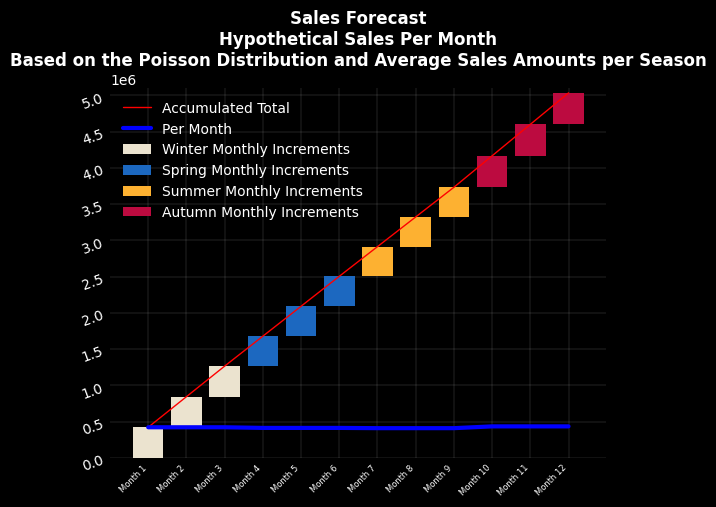

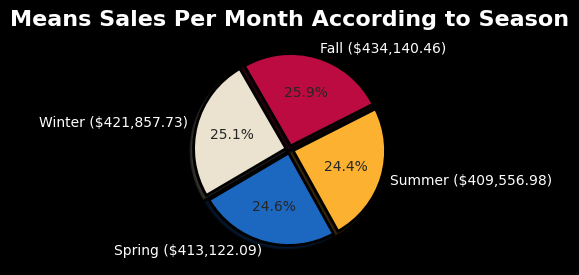

In [26]:
def y_lims_ticks(y,interval=0.25):
    mn,mx=y[0],y[-1]
    spots=1
    places=0
    while spots<=mx:
        spots*=10
        places+=1
    spots//=10
    spots//=10
    mx+=spots
    mx//=spots
    mx*=spots
    whole_tick=spots*10
    ticks=[0]
    while ticks[-1]<mx:
        tick=ticks[-1]+whole_tick*interval
        ticks.append(tick)
    return (mn//spots,mx),ticks

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-dark')

def predict_total_sales_per_season(df):
    winter=simulate_sales_by_season(df,'Winter',364/4).sum()
    spring=simulate_sales_by_season(df,'Spring',364/4).sum()
    summer=simulate_sales_by_season(df,'Summer',364/4).sum()
    fall=simulate_sales_by_season(df,'Fall',364/4).sum()
    return [winter,spring,summer,fall]

seasons=predict_total_sales_per_season(df)

def occurance_per_season_data(period_to_aggrigate:str='Months'):
    """
    this takes the period to aggrigate: one of ['month','week','quarter','season']
    """
    #edge case where input might be plural
    if period_to_aggrigate[-1] in ('s','S'):
        period_to_aggrigate=period_to_aggrigate[:-1]
    #edge case to make period non-case sensitive
    period_to_aggrigate=period_to_aggrigate.lower()    
    #calculate period size    
    period_sizes = {'week':365/52,'month':365/12,'quarter':365/4,'season':365/4}
    period_size_in_days = period_sizes[period_to_aggrigate]
    #calculate numer of periods in each season: season_days/period_days
    periods_per_season= int( period_sizes['quarter'] / period_size_in_days )
    #call to get sums of predicted sales for given periods

    global seasons
    try:                      
        if not seasons:
            global df  ########################################################################################======--------->>>>>this needs to be cleaner<<<<<<<-----------=========#################################################
            seasons=predict_total_sales_per_season(df) 
        else:
            partitioned_seasons=[season/periods_per_season for season in seasons]
    except:
            pass     # message to run the line seasons=predict_total_sales_per_season(df) outsice of this function or to write such a line 
    # return the name of the period, the period size in days, and number of periods per season(quarter)
    return partitioned_seasons, period_to_aggrigate, period_size_in_days, periods_per_season
        
#get period for periods <= season size
#   USER INPUT REQUIRED
# CREATE A DICT 
period_details = {'w':None,'m':None,'q':None} #[partitioned_seasons, period_to_aggrigate, period_size_in_days, periods_per_season]+[period_title,total_periods,zero_to_max,starts,periods]
# retrieve the predicted sales per period by season, name of the period such as week or month, the period size in days, and number of periods per season(quarter)
def update_period_details(period:str='Months'):
    period=period.lower()
    if period in ['quarter','quarters','season','seasons','month','months','week','weeks']:
        if period[0]=='s':
            p='q'
        else: p=period[0]
    else:
        raise ValueError(f"Please enter one of: Months, Weeks, Quarters, or Seasons")
    global period_details
    period_details[p]=list(occurance_per_season_data(period))
    


def get_plot_data(period_:str='Month'):
    """

    """
    #4 seasons per year
    num_seasons=4

    global period_details
    #retrieve or create period data
    period_=period_.lower()
    p=period_[0]
    if p=='s':p='q'

    try:
        res=period_details[p]
        period_title,total_periods,zero_to_max,starts,periods=res[4],res[5],res[6],res[7],res[8]
        return period_title,total_periods,zero_to_max,starts,periods
    except:
        if period_details[p] is None:
            update_period_details(period_)
            res=period_details[p]
            partitioned_seasons, period_to_aggrigate, period_size_in_days, periods_per_season=res[0],res[1],res[2],res[3]
        else:
            res=period_details[p]
            partitioned_seasons, period_to_aggrigate, period_size_in_days, periods_per_season=res[0],res[1],res[2],res[3]  
        #iterate through seasons and periods within seasons
        #capture period totals and start points for later plot
        periods=[]
        starts=[]
        start=0
        for  season in partitioned_seasons:
            for period in range(int(periods_per_season)):
                if len(periods)<=0:
                    periods.append(season)
                    starts.append(start)
                    start+=season
                else:
                    starts.append(start)
                    start+=season
                    periods.append(season)

        period_title=period_to_aggrigate.title()
        total_periods=int(num_seasons*periods_per_season)
        zero_to_max=(0,start)
        starts,periods=starts,periods
        period_details[p]+=[period_title,total_periods,zero_to_max,starts,periods]

# CALLABLE-----------------------------------------------------------
def floating_bar_plot(period_:str="Month",y_tick_aggregate_3rd_highest_nplace=0.5):
    """
    where y_tick_aggregate_3rd_highest_nplace sets the interval of ticks based on 3 place from left of int


    """
    if period_[-1] in ['s','S']:
        period_=period_[:-1]
    global period_details
    #retrieve or create period data
    period_=period_.lower()
    if period_ not in ['month','week','quarter','season']:
        raise ValueError(f"Please enter one of: Month, Week, Quarter, or Season")
    p=period_[0]
    if p=='s':p='q'
    try:
        res=period_details[p]
        periods_per_season,period_title, total_periods, zero_to_max,starts,periods=res[3],res[4],res[5],res[6],res[7],res[8]
    except:
        get_plot_data(period_)
        res=period_details[p]
        periods_per_season,period_title, total_periods, zero_to_max,starts,periods=res[3],res[4],res[5],res[6],res[7],res[8]

    #NOTE TO STORE THESE COMPREHENSIONS IN A DICTIONARY
    if period_title!='Week':
        x_ticks = [f"{period_title} {i+1}" for i in range(len(periods))]
    else:
        x_ticks = [f"{period_title} {i+1}" if int((i+1)%13)==1 else str(i+1) for i in range(len(periods))]


    # Set global style for offset/scientific notation text
    plt.rcParams['axes.formatter.limits'] = (-3, 3)   # force sci notation when needed
    plt.rcParams['axes.formatter.useoffset'] = True   # show offset text
    plt.rcParams['xtick.color'] = 'white'             # x-axis ticks
    plt.rcParams['ytick.color'] = 'white'             # y-axis ticks
    plt.rcParams['axes.labelcolor'] = 'white'         # axis labels
    plt.rcParams['axes.edgecolor'] = 'white'          # axis spines

    #use partitions and starts to form the plot
    sns.lineplot(x=x_ticks,y=np.array(starts)+np.array(periods),linewidth=1,label='Accumulated Total',color='red')
    sns.lineplot(x=x_ticks,y=periods,color='blue',linewidth=3,label=f"Per {period_title}")

    # as per output of predict_total_sales_per_season(df), seasons are ordered as winter, spring, summer, fall
    season_colors=['#EBE3CF','#1c68c0','#FDB131','#BC0B40']
    season_names=['Winter','Spring','Summer','Autumn']
    color_index=0
    increment_step=int(periods_per_season)
    for season in range(0,total_periods,increment_step):
        sea=season_names[color_index]
        color=season_colors[color_index]
        color_index+=1
        plt.bar(x=x_ticks[season:season+increment_step], height=periods[season:season+increment_step], bottom=starts[season:season+increment_step],label=f"{sea+' '+period_title}ly Increments",color=color)
    plt.xticks(x_ticks,rotation=45,fontsize=6,ha='right',color='white')
    y_lim,y_ticks=y_lims_ticks(zero_to_max,y_tick_aggregate_3rd_highest_nplace)
    plt.yticks(y_ticks,rotation=20,color='white')
    plt.title(f"Sales Forecast\nHypothetical Sales Per {period_title}\nBased on the Poisson Distribution and Average Sales Amounts per Season",fontweight='bold',color='white')
    plt.ylim(y_lim)
    plt.gcf().set_facecolor("black")   # parchment background
    plt.gca().set_facecolor("black") 
    leg = plt.legend()
    for text in leg.get_texts():
        text.set_color("white")
    plt.grid(linewidth=.1)
    plt.show()
    #st.pyplot(plt)   ### <<----------------------------------------<< for streamlit
#plt.figure(figsize=(8,3))
floating_bar_plot('month')


# CALLABLE-----------------------------------------------------------
def plot_mean_seasonal_sales(period_:str="Month"):
    """

    """
    global seasons, period_details
    period=period_.lower()
    if period in ['quarter','quarters','season','seasons','month','months','week','weeks']:
        if period[0]=='s': 
            p='q'
        else: p=period[0]
    else:
        raise ValueError(f"Please enter one of: Months, Weeks, Quarters, or Seasons")
    try:
        if p in ('q','s'):
            values=seasons
        else:
            values=period_details[p][0]
    except:
        period_details[p]=list(occurance_per_season_data(period))
        values=period_details[p][0]
    #period_title=period_details[p][1].title()
    labels = ['Winter','Spring','Summer','Fall'] 
    plt.figure(figsize=(3, 3))
    wedges,texts,autotexts = plt.pie(
        values,
        labels=[f"{labels[i]} (${values[i]:,.2f})" for i in range(len(values))],
        autopct='%1.1f%%',              
        startangle=120,               
        colors=['#EBE3CF','#1c68c0','#FDB131','#BC0B40'], 
        wedgeprops={'edgecolor':'black','linewidth':2},
        explode=[0.04]*4,
        shadow=True
    )
    for text in texts:
        text.set_color('white')
    title_=f"{period_.title()} According to Season" if not period_.title().startswith('Sea') and not period_.title().startswith('Qua') else period_.title()
    plt.title(f"Means Sales Per {title_}",
            fontsize=16, fontweight='bold',color='white')
    plt.gcf().set_facecolor('black')
    plt.show()
    #st.pyplot(plt)   ### <<----------------------------------------<< for streamlit

plot_mean_seasonal_sales('month') 


In [27]:

class MuEstimator:
   

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Z AND T SCORES :--> 1 for proportion estimation and  2 tail for linear estimation
    # one_tailed_t_score_lookup(), two_tailed_t_score_lookup(), one_tailed_z_score_lookup(), two_tailed_z_score_lookup()


    def two_tailed_z_score_lookup(self, confidence_level: float = 0.95):
        two_tail = (1 + confidence_level) / 2
        z_score = scipy.stats.norm.ppf(two_tail)    
        return z_score

    def one_tailed_z_score_lookup(self, confidence_level: float = 0.95):
        # For one-tailed, we use the confidence level directly
        one_tail = confidence_level
        z_score = scipy.stats.norm.ppf(one_tail)        
        return z_score


    def two_tailed_t_score_lookup(self, dof,confidence_level: float = 0.95):
        """
        Return the critical t-score for a two-tailed confidence interval.
        
        Parameters:
            confidence_level (float): Desired confidence level (default 0.95).
            df (int): Degrees of freedom (sample size - 1).
        
        Returns:
            float: Critical t-score.
        """
        alpha = 1 - confidence_level
        return scipy.stats.t.ppf(1 - alpha/2, dof)        
        
    
    def one_tailed_t_score_lookup(self, dof,confidence_level: float = 0.95):
        """
        Return the critical t-score for a one-tailed confidence interval.
        
        Parameters:
            confidence_level (float): Desired confidence level (default 0.95).
            df (int): Degrees of freedom (sample size - 1).
        
        Returns:
            float: Critical t-score.
        """
        alpha = 1 - confidence_level
        return scipy.stats.t.ppf(1 - alpha, dof)        
        

    #--------------------------------------------------------------------------------------------------------------------------------------------------
    # PROPORTION PROBABILITIES FOR SPARSE AND OTHERWISE 
    # PROPORTION STANDARD ERROR(SE) 
    # LINEAR STANDARD ERROR(SE)

    def proportion_one_hot(self,vec):
        """
        accepts a vector of [True,False]'s or [1,0]'s
        Compute the proportion of True/False (or 1/0) in a vector.
        Works with numpy arrays, pandas Series, and cudf Series.
        Parameters
        ----------
        vec : numpy.ndarray, pandas.Series, or cudf.Series
            Sparse vector containing [1,0] or [True,False].
        Returns
        -------
        dict
            {"True": proportion_true, "False": proportion_false}
        """
        # Convert to numpy array for uniform handling
        try:
            arr = vec.values  # pandas or cudf
        except AttributeError:
            arr = vec         # numpy already
        # normalize to boolean
        arr = np.asarray(arr).astype(bool)  
        total = arr.size
        if total == 0:
            return {"True": 0.0, "False": 0.0}
        true_count = arr.sum()
        false_count = total - true_count
        return {
            "True": true_count / total,
            "False": false_count / total        }
    

    def proportion_successes(self,denominator, successes):
        """
        Compute the proportion of successes to denominator.
        Works with numpy arrays, pandas Series, and cudf Series.
        Parameters
        ----------
        denominator : numpy.ndarray, pandas.Series, or cudf.Series
            Vector of denominator counts (must be >0).
        successes : numpy.ndarray, pandas.Series, or cudf.Series
            Vector of success counts (must be <= denominator).
        Returns
        -------
        numpy.ndarray
            Array of proportions (successes / denominator).
        """
        # Convert both inputs to numpy arrays for uniform handling
        try:
            denominator_arr = denominator.values  # pandas or cudf
        except AttributeError:
            denominator_arr = denominator
        try:
            successes_arr = successes.values
        except AttributeError:
            successes_arr = successes
        denominator_arr = np.asarray(denominator_arr, dtype=float)
        successes_arr = np.asarray(successes_arr, dtype=float)
        # Safety checks
        if denominator_arr.shape != successes_arr.shape:
            raise ValueError("denominator and successes must have the same shape.")
        if np.any(denominator_arr < 0):
            raise ValueError("No denominator can be < 0")
        if np.any(successes_arr > denominator_arr):
            raise ValueError("Successes cannot exceed denominator.")
        
        no_denominator_indexes=denominator_arr==0
        if np.any(no_denominator_indexes):
            warnings.warn("Warning: some denominator are zero; proportions will include NaN values.")
        #create an empty array for index masking
        proportions = np.empty_like(denominator_arr, dtype=float)
        proportions[~no_denominator_indexes] = successes_arr[~no_denominator_indexes] / denominator_arr[~no_denominator_indexes]
        proportions[no_denominator_indexes] = np.nan 
        return proportions    

    #standard error for continious or discrete data
    def se_mean(self,sample_std, n_of_population):
        """
        Compute standard error of the mean: s / sqrt(n).        
        Parameters
        ----------
        s : scalar, list, numpy.ndarray, pandas.Series, or cudf.Series ==>Standard deviation(s).
        n : scalar, list, numpy.ndarray, pandas.Series, or cudf.Series ==>Sample size(s).        
        Returns -------> Same type as input --------> Standard error(s).
        """
        s_arr = np.asarray(sample_std, dtype=float)
        n_arr = np.asarray(n_of_population, dtype=float)
        result = s_arr / np.sqrt(n_arr)
        return result

    #standard error for proporitons
    def se_proportion(self,proportion, denominator):
        """
        Compute standard error of a proportion: sqrt(p*(1-p)/n).    
        Parameters
        ----------
        p : scalar, list, numpy.ndarray, pandas.Series, or cudf.Series ==>Proportion(s).
        n : scalar, list, numpy.ndarray, pandas.Series, or cudf.Series ==>Sample size(s).    
        Returns -------> Same type as input  -------> Standard error(s).
        """
        p_arr = np.asarray(proportion, dtype=float)
        n_arr = np.asarray(denominator, dtype=float)
        result = np.sqrt((p_arr * (1 - p_arr)) / n_arr)
        return result
    
    def margin_of_error(self,statistic, standard_error):
        """
        Compute margin of error: statistic * standard error.        
        Parameters
        ----------
        statistic : scalar, list, numpy.ndarray, pandas.Series, or cudf.Series ==> Statistic(s) (e.g., z-score or t-score).
        se : scalar, list, numpy.ndarray, pandas.Series, or cudf.Series ==>  Standard error(s).        
        Returns   ------>   Same type as input   ------> Margin of error(s).
        """
        stat_arr = np.asarray(statistic, dtype=float)
        se_arr = np.asarray(standard_error, dtype=float)

        if stat_arr.shape != se_arr.shape:
            raise ValueError("Statistic and SE must have the same shape.")

        result = abs(stat_arr * se_arr)
        return result
    
    #-----------------------------------------------------------------------------------------------------------------------------------------------------
    #mu estimators

    #mu of continuous or discrete data
    def mean_estimator(self, mean, sample_std, num_observations, confidence_level,MOE_only=False):
        """

        """
        try:
            mean_arr = mean.values  # pandas or cudf
        except AttributeError:
            mean_arr = mean
        try:
            sample_std_arr = sample_std.values
        except AttributeError:
            sample_std_arr = sample_std
        try:
            num_observations_arr = num_observations.values
        except AttributeError:
            num_observations_arr = num_observations
        mean_arr = np.asarray(mean_arr, dtype=float)
        sample_std_arr = np.asarray(sample_std_arr, dtype=float)
        num_observations_arr = np.asarray(num_observations_arr, dtype=float)
        
        #build an empty statistic vector
        statistics=np.empty_like(num_observations,dtype=float)
        #identify indexes with num observations <30
        obs_under_30=num_observations_arr<30
        #steps:
        #determine t scores for low observation datapoints
        #a scalar z 
        statistics[obs_under_30]=self.two_tailed_t_score_lookup( num_observations_arr[obs_under_30]-1,confidence_level)
        z_statistic=self.two_tailed_z_score_lookup(confidence_level)
        statistics[~obs_under_30]=z_statistic

        #make call to get standard errors
        standard_errors = self.se_mean(sample_std_arr, num_observations_arr)
        #make call to get MOE
        MOE = self.margin_of_error(statistics, standard_errors)
        if MOE_only==True:
            return MOE
        #calculate bounds
        lower , upper = mean_arr-MOE , mean_arr+MOE
        """
        #return according to mean input datatype
        if isinstance(mean, pd.Series):
            return pd.DataFrame({"lower": lower, "upper": upper}, index=mean.index)
        try:
            if isinstance(mean, cudf.Series):
                return cudf.DataFrame({"lower": lower, "upper": upper}, index=lower.index)
        except NameError:
            pass
        if isinstance(mean, list):
            return list(zip(lower, upper))"""
        return np.column_stack((lower, upper))  # default NumPy



    #mu of proportion data
    def proportion_estimator(self, proportions, num_observations, confidence_level,MOE_only=False):
        """

        """
        try:
            proportions_arr = proportions.values  # pandas or cudf
        except AttributeError:
            proportions_arr = proportions
        try:
            num_observations_arr = num_observations.values
        except AttributeError:
            num_observations_arr = num_observations
        proportions_arr = np.asarray(proportions_arr, dtype=float)
        num_observations_arr = np.asarray(num_observations_arr, dtype=float)
        
        #build an empty statistic vector
        statistics=np.empty_like(num_observations,dtype=float)
        #identify indexes with num observations <30
        obs_under_30=(num_observations_arr<30)&~np.isnan(proportions_arr)
        obs_equal_to_or_over_30=(num_observations_arr>=30)&~np.isnan(proportions_arr)
        isnull_indexes=np.isnan(proportions_arr)    
        #create empty arrays for masking values into
        standard_errors = np.empty_like(proportions_arr,dtype=float)
        MOE = np.empty_like(statistics,dtype=float)
        lower,upper=np.empty_like(proportions_arr,dtype=float),np.empty_like(proportions_arr,dtype=float)
        #retrieve z stat        
        z_statistic=self.one_tailed_z_score_lookup(confidence_level)
        #steps:
        #determine t scores for low observation datapoints
        #a scalar z
        #make call to get standard errors
        #make call to get MOE
        #calculate bounds
        statistics[obs_under_30]=self.one_tailed_t_score_lookup(num_observations_arr[obs_under_30]-1,confidence_level)
        statistics[obs_equal_to_or_over_30]=z_statistic
        standard_errors[~isnull_indexes] = self.se_proportion(proportions_arr[~isnull_indexes], num_observations_arr[~isnull_indexes]) 
        MOE[~isnull_indexes] = self.margin_of_error(statistics[~isnull_indexes], standard_errors[~isnull_indexes])
        if MOE_only==True:
            return MOE
        lower[~isnull_indexes] , upper[~isnull_indexes] = proportions_arr[~isnull_indexes]-MOE[~isnull_indexes] , proportions_arr[~isnull_indexes]+MOE[~isnull_indexes]
        """
        #return according to mean input datatype
        if isinstance(proportions, pd.Series):
            return pd.DataFrame({"lower": lower, "upper": upper}, index=proportions.index)
        try:
            if isinstance(proportions, cudf.Series):
                return cudf.DataFrame({"lower": lower, "upper": upper}, index=lower.index)
        except NameError:
            pass
        if isinstance(proportions, list):
            return list(zip(lower, upper))"""
        return np.column_stack((lower, upper))  # default NumPy



In [28]:
#functions to return grouped dataframes with mu estimates
#will need MuEstimator
#
#
#


def filter_data_by_season(df,season_column:str,season:str):
    return df.loc[df[season_column]==season]

# these 3 call MuEstimator()

def get_single_variable_proportions(product_column: pd.Series) -> pd.DataFrame:
    """
    takes a series as input and returns a dataframe with proportions
    """
    counts = product_column.value_counts()
    num_observations=[counts.sum()]*len(counts.index)    
    proportions = MuEstimator().proportion_successes(num_observations,counts)
    cat_var='category_variable' if product_column.name is None else product_column.name
    return pd.DataFrame({cat_var:counts.index,'proportion':proportions,'num_observations':num_observations,'successes':counts.values})


def get_bivariable_proportions(dataframe, partition_variable:list, category_variable:str):
    """
    takes a dataframe, a partition columns, and a target column as input. returns a new dataframe with proportions
    """
    data=dataframe.copy()
    data=df.groupby(partition_variable+[category_variable],as_index=False,observed=True).size().rename(columns={'size':'successes'})##<<<-----this should be returned for count plots
    sizes=df.groupby(category_variable,as_index=False,observed=True).size().rename(columns={'size':'num_observations'})
    data = data.merge(sizes,how='left',right_on=category_variable,left_on=category_variable)
    data['proportion'] = MuEstimator().proportion_successes(data['num_observations'],data['successes'])
    data=data.reset_index(drop=False)
    return data[partition_variable+[category_variable,'proportion','num_observations','successes']]


#-----------------------------------------------------------------------------------------------------------------------------------------
# Create grouped mu estimate range dataframes


def get_proportion_estimate_df(dataframe:pd.DataFrame,target_col:str,confidence_level:float=0.95,partition_by:list=None):
    """
    takes a dataframe, target column, confidence interval[default 0.95], optional partition column(s)[default None], and sort[default None] as input.
    returns a new dataframe with <partition column>, target column, num_observations column, upper column, and lower column.
    where upper and lower are the mu estimate intervals
    if sort is not None, it should be one of True or False to indicate ascending=True/False proportions
    """
    if partition_by is None or partition_by == []:
        estimate_df=get_single_variable_proportions(dataframe[target_col])
    else:
        estimate_df=get_bivariable_proportions(dataframe, partition_by, target_col)
    if confidence_level>0.999999:
        raise ValueError('Confidence Level Out of Bounds\nexceeds-->0.999999')
    estimate=MuEstimator().proportion_estimator(estimate_df['proportion'],estimate_df['num_observations'],confidence_level)
    estimate_df['lower'],estimate_df['upper'] = estimate[:,0],estimate[:,1]
    if partition_by!=None or partition_by!=[]:
        estimate_df=estimate_df.sort_values(by=[target_col]+['successes','proportion']+partition_by,ascending=[False,True,True]+[False for i in partition_by]).reset_index(drop=True)
    else: 
        estimate_df=estimate_df.sort_values(by=[target_col,'successes','proportion'],ascending=[False,True,True]).reset_index(drop=True)        
    return estimate_df



def get_mean_estimate_df(df,target_col:str,confidence_level:float=0.95,partition_cols:list=None):
    """
    takes dataframe, a target column, a confidence interval[default 0.95], a list of 0 to n partition columns to group by, and sort[default None].
    return a grouped dataframe with aggregated columns: 'min','mean','median','max','std','size','lower','upper'
    if sort is not None, it should be one of True or False to indicate ascending=True/False for sort by 'mean'
    """
    if partition_cols==None or partition_cols==[]:
        estimate_df = pd.DataFrame({target_col:[target_col],'min':[df[target_col].min()],'mean':[df[target_col].mean()],'median':[df[target_col].median()],'max':[df[target_col].max()],'std':[df[target_col].std()],'size':[df[target_col].count()]})
    else:
        estimate_df = df.groupby(partition_cols,as_index=False,observed=True)[target_col].agg(['min','mean','median','max','std','size'])
    estimates=MuEstimator().mean_estimator(estimate_df['mean'],estimate_df['std'],estimate_df['size'],confidence_level)
    estimate_df['lower'],estimate_df['upper'] = estimates[:,0],estimates[:,1]
    if partition_cols!=None or partition_cols!=[]:
        estimate_df=estimate_df.sort_values(by=['size','mean']+partition_cols,ascending=[True,True]+[False for i in partition_cols]).reset_index(drop=True)
    else:
        estimate_df=estimate_df.sort_values(by=['size','mean'],ascending=[True,True]).reset_index(drop=True)
    return estimate_df

# get plot data
#df,target_col:str,confidence_level:float=0.95,partition_by:list=None,sort=None
#df,target_col:str,confidence_level:float=0.95,partition_cols:list=None,sort=None
def get_floating_mu_hbar_plot_data(plot_df_:pd.DataFrame,target_col:str,partition_cols:list):
    """
    return lefts,mu,median,widths,Y_ticks,X_label,intersects,target_col
    where lefts is lower bounds, mu is mu, media is median or none in case of proportions, widths is MOE*2, 
    Y_ticks is concatenated partition feature labels, 
    X_label is target col w/ partitions by feature label, 
    intersects is a list of feature partitions, 
    target col is the string title of the target col that represents the mu
    """
    
    plot_df=plot_df_.copy()
    if target_col not in plot_df.columns:
        plot_df[target_col]=target_col
    '''plot_df=plot_df.sort_values(by=partition_cols+[target_col,'size'],ascending=[True for i in partition_cols+[target_col]]+[False]).reset_index(drop=True)
    else:
        plot_df=plot_df_.copy().sort_values(by=partition_cols+[target_col,'successes'],ascending=[True for i in partition_cols+[target_col]]+[False]).reset_index(drop=True)'''
    partitions=False if partition_cols is None or partition_cols==[] else True
    if partitions==True:
        Y_ticks="] -> "+plot_df[target_col].astype(str)
    else: Y_ticks=plot_df[target_col].astype(str)
    first=True  # to help with string format
    for col in partition_cols: 
        if first==False:
            Y_ticks="'"+plot_df[col].astype(str)+"', "+Y_ticks.astype(str)
        else:
            Y_ticks="'"+plot_df[col].astype(str)+"'"+Y_ticks.astype(str)
            first=False
    if partitions==True:
            Y_ticks="["+Y_ticks.astype(str)
    Y_ticks=Y_ticks.values
    #X_label    
    X_label=target_col+'\nPartitioned By\n'+str(partition_cols) if partitions==True else target_col.title()
    

    #extract plot data  {upper and lower are used to calculate lefts and widths
    #check categorical or continuous
    mu_is_mean=True if 'mean' in plot_df_.columns else False     
    if mu_is_mean==True: 
        lefts,mu,median,widths,counts =  plot_df['lower'].values, plot_df['mean'].values, plot_df['median'].values, (plot_df['upper']-plot_df['lower']).values, plot_df['size'].values
    else:
        lefts,mu,widths,counts=plot_df['lower'].values, plot_df['proportion'].values, (plot_df['upper']-plot_df['lower']).values, plot_df['successes'].values 
        median=None
    intersects = partition_cols if partition_cols is not None else []
    return lefts,mu,median,widths,Y_ticks,X_label,intersects,counts,target_col

def plot_floating_mu_hbar(lefts,mu,median,widths,Y_ticks,X_label,intersects,counts,target_col,confidence_level,legend_median=True,plot_title=None):
    """
    accepts data produced direct from get_floating_mu_hbar_plot_data(); plus plot_title
    
    """  
    if median is None: mu_is_mean=False
    else: mu_is_mean=True
    if plot_title is None: 
            plot_title=f"{target_col.title()}"
    common_fontsize = 16
    scatter_dot_size=3.1415926535 * (common_fontsize / 2) ** 2   #####need a formula to convert fontsize to to area of a circle 
    mu_color="#09145A"
    median_color="#A61313"
    mu_median_edgecolor="white"
    bar_color="#646B7BED"
    legend_text_color='white'
    figure_color='black'
    axis_color='black'  
    num_y_ticks=len(Y_ticks)
    count_color="#4B0707"
    text_color='white'

    row_height_in = common_fontsize / 72 * 1.6   # points → inches
    fig_height = max(6, (len(Y_ticks) * row_height_in)+2)

    sns.set_theme(
        rc={
            "figure.figsize": (20, fig_height),
            "figure.titlesize": common_fontsize*1.75,
            "font.size": common_fontsize,
            "axes.labelsize": common_fontsize,
            "axes.titlesize": common_fontsize*1.5,
            "xtick.labelsize": common_fontsize,
            "ytick.labelsize": common_fontsize,
            "legend.fontsize": common_fontsize,
            "axes.formatter.limits": (-3, 5),
            "axes.formatter.useoffset": True,
            "axes.titlecolor": text_color,
            "xtick.color": text_color,
            "ytick.color": text_color,
            "axes.labelcolor": text_color,
            "axes.edgecolor": "black",
            "legend.labelcolor": text_color,
        }   )

    fig, ax = plt.subplots(1,2)
    plt.subplot(1,2,1)
    ax[0].barh(
        y=np.arange(num_y_ticks),     # numeric positions = better control
        width=widths,
        left=lefts,
        color=bar_color,
        edgecolor=bar_color,
        label="Confidence Interval"
    )

    if mu_is_mean and legend_median==True:
        ax[0].scatter(
            median, np.arange(num_y_ticks),
            color=median_color,
            edgecolor=mu_median_edgecolor,
            s=scatter_dot_size,
            label="Median"
        )

    center_label = "Mean" if mu_is_mean else "Proportion"
    ax[0].scatter(
        mu, np.arange(num_y_ticks),
        color=mu_color,
        edgecolor=mu_median_edgecolor,
        s=scatter_dot_size,
        label=center_label
    )

    ax[0].set_yticks(np.arange(num_y_ticks))
    ax[0].set_yticklabels(Y_ticks)
    ax[0].tick_params(axis="y", pad=6)
    ax[0].set_ylim(-0.5, num_y_ticks - 0.5)

    ax[0].set_xlabel(X_label)
    ax[0].tick_params(axis="x", labelrotation=45)
    for label in ax[0].get_xticklabels():
        label.set_ha("right")
    '''if not mu_is_mean:
        ax[0].set_xlim((0,1))'''

    ax[0].set_facecolor(axis_color)
    ax[0].grid(linewidth=0.3,which='both')
    ax[0].set_title(f'{confidence_level}% Confidence Level')
    
    plt.subplot(1,2,2)
    center_label = "Mean" if mu_is_mean else "Proportion"
    sns.barplot(
        x=counts,
        y=Y_ticks,
        orient="h",
        ax=ax[1],
        color=count_color,
        edgecolor=count_color,
        label='Counts'
    )
    ax[1].legend_.remove()

    ax[1].set_yticks(np.arange(num_y_ticks))
    ax[1].set_yticklabels(['']*num_y_ticks)
    ax[1].tick_params(axis="y", pad=6)
    ax[1].set_ylim(-0.5, num_y_ticks - 0.5)

    ax[1].set_xlabel('Count Within Group(s)')
    ax[1].tick_params(axis="x", labelrotation=45)
    for label in ax[1].get_xticklabels():
        label.set_ha("right")
 
    ax[1].set_facecolor(axis_color)
    ax[1].grid(linewidth=0.3,which='both')
    ax[1].set_title('Count(s)')

    fig.suptitle(
        f"\n\n{plot_title}",
        color=text_color,
        y=1
    )

    fig.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1),
        ncol=3 if not mu_is_mean or legend_median==False else 4,
        frameon=False
    )
    
    fig.patch.set_facecolor(figure_color)
    plt.tight_layout()
    plt.show()
    #st.pyplot(plt)   ### <<----------------------------------------<< for streamlit
 


def get_floating_proportion_hbar(dataframe:pd.DataFrame,target_col:str,confidence_level:float=0.95,partition_by:list=[],plot_title=None):
    """
    
    """
    mu_data = get_proportion_estimate_df(dataframe,target_col,confidence_level,partition_by)
    plot_data = get_floating_mu_hbar_plot_data(mu_data,target_col,partition_by)
    #generate plot
    plot_floating_mu_hbar(*plot_data,confidence_level,plot_title=plot_title)

   
def get_floating_mean_hbar(dataframe:pd.DataFrame,target_col:str,confidence_level:float=0.95,partition_by:list=None,plot_title=None,median=False):
    """
    
    """
    mu_data = get_mean_estimate_df(dataframe,target_col,confidence_level,partition_by)
    plot_data = get_floating_mu_hbar_plot_data(mu_data,target_col,partition_by)
    #generate plot
    plot_floating_mu_hbar(*plot_data,confidence_level,plot_title=plot_title,legend_median=median)




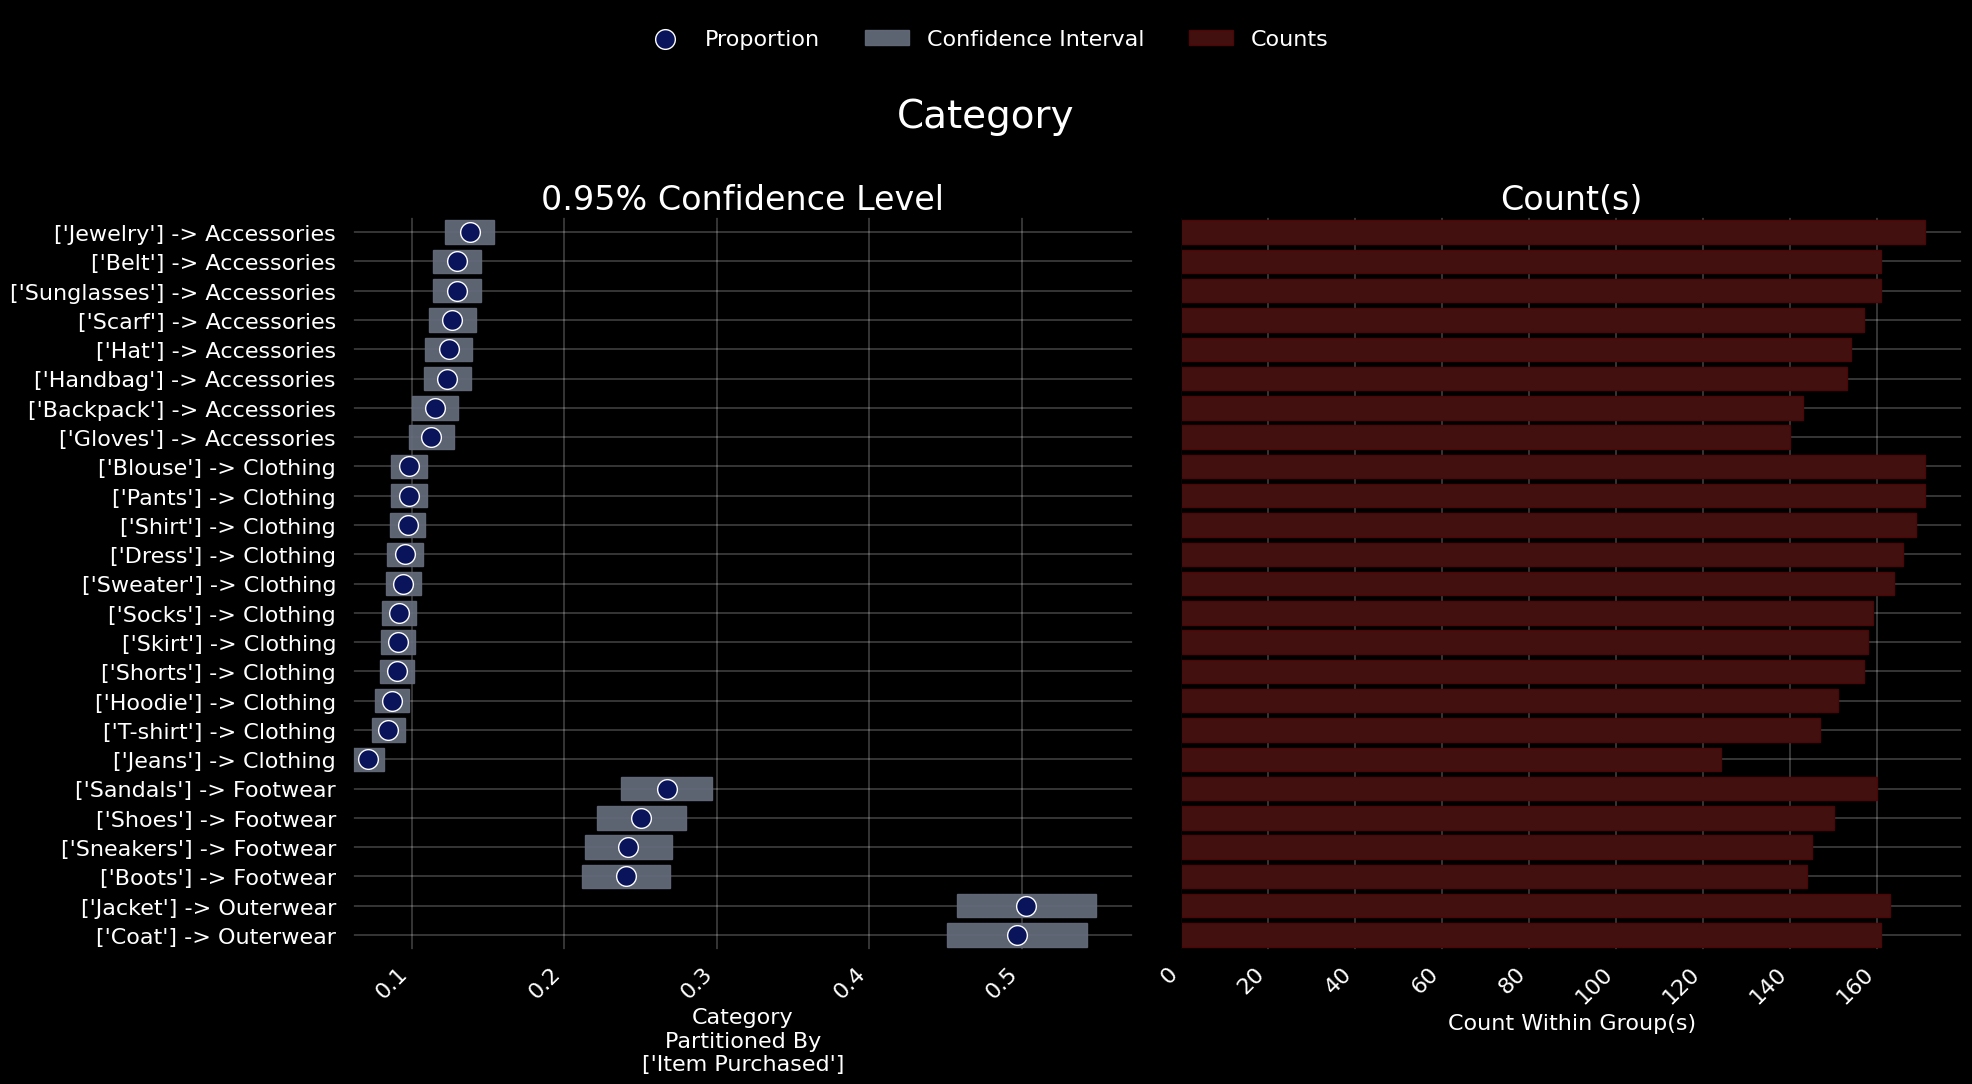

In [29]:

target_col, confidence_level, partition_by = 'Category',.95,['Item Purchased']

disp_df = get_proportion_estimate_df(df,target_col,confidence_level,partition_by)
#display(disp_df)
get_floating_proportion_hbar(df,target_col,confidence_level,partition_by,plot_title=None)



In [30]:
df['Gender'].value_counts().sum()

np.int64(3900)

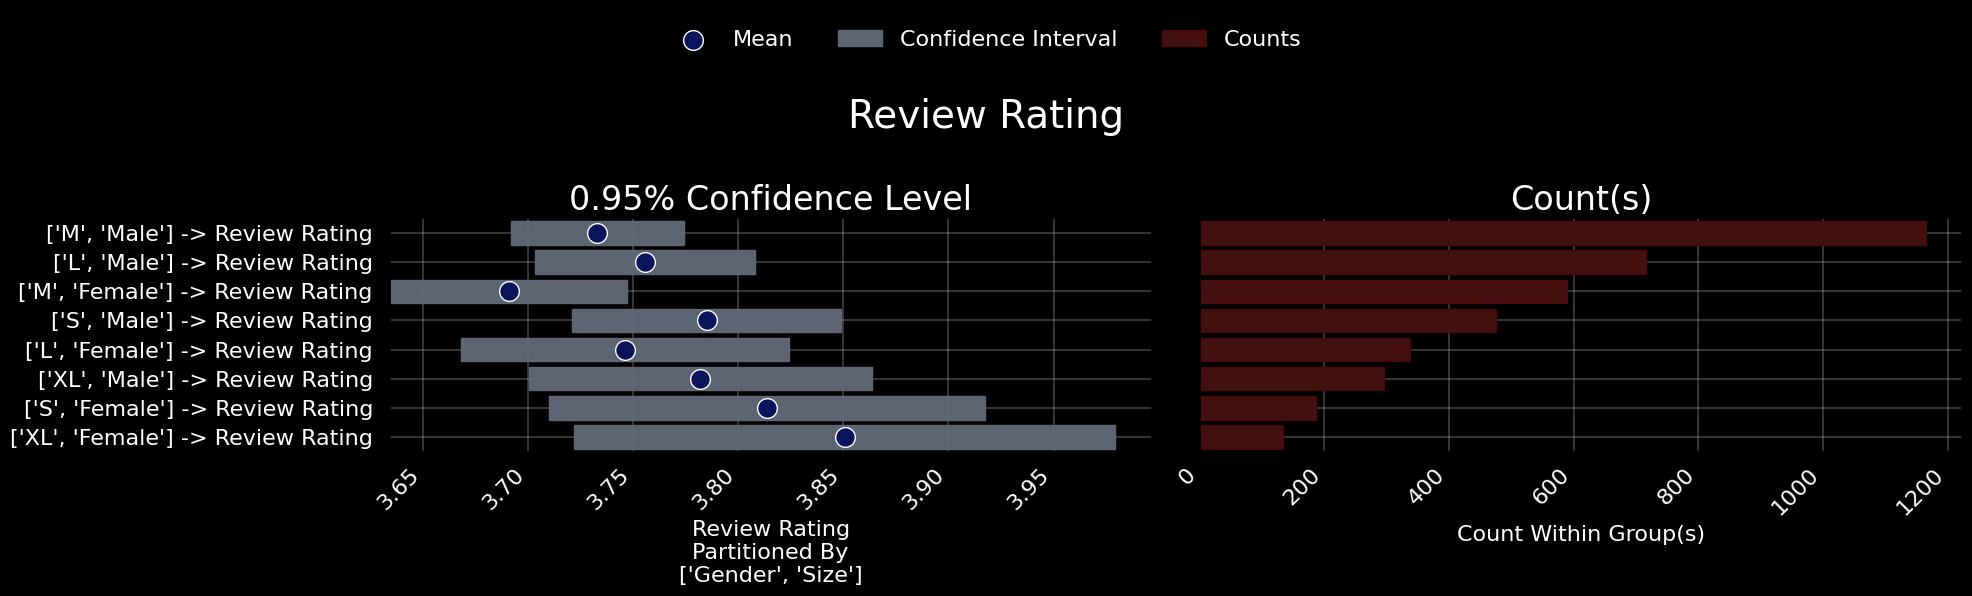

In [31]:

target_col2,confidence_level2,partition_by2 = 'Review Rating',0.95,['Gender','Size']

disp_df2 = get_mean_estimate_df(df,target_col2,confidence_level2,partition_by2)
#display(disp_df2)
get_floating_mean_hbar(df,target_col2,confidence_level2,partition_by2,plot_title=None,median=False)

In [32]:
#rough skew > 3( (mean-median)/q )
#skewness > [( sum(x-mu)**3 )/n]/q**3   ---> where -/+ indicate left/right

#kurtosis > [( sum(x-mu)**4)/n]/q**4    ---> where normal is 3

pipe, such as cleaning and preprocessing, normality and uniform tests, pca <--and--> regression, anova(-Ts), chi, kmeans, reiterate chi and anova-(Ts) on clusters,   


must have (edge case func to ensure column headers are not used as groupby columns such as 'size' and 'Size' in this dataset is close to a problem